In [1]:
!pip install wbgapi # Instalar wbgapi que será usado para os nossos dados.

In [2]:
import pandas as pd
import numpy as np
import wbgapi as wb
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
import re
import json
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

In [3]:
# 1. Definir os indicadores do Banco Mundial
indicators = {
    'NY.GDP.PCAP.CD': 'PIB_per_Capita',
    'NY.GDP.MKTP.CD': 'PIB_Bruto_USD',
    'FP.CPI.TOTL.ZG': 'Inflacao_Anual',
    'SP.DYN.LE00.IN': 'Esperanca_Vida',
    'SH.DYN.MORT': 'Mortalidade_Infantil'
}

# 2. Definir os países e o período (últimos 10 anos)
paises = 'all'
anos = range(2014, 2024) # Alguns dados de 2024 existem, mas pela maioria ser NULL (e no outro dataset ser completamente NULL) usamos 2023 como o máximo.

df_worldbank = wb.data.DataFrame(indicators.keys(), time=anos, labels=True).reset_index()
df_worldbank.rename(columns=indicators, inplace=True)
# Remover agregados (o world bank possui dados agregados relativos a regiões gerais (continentes) e mundiais)
agregados = [e['id'] for e in wb.economy.list() if e['aggregate'] == True]
df_worldbank = df_worldbank[~df_worldbank['economy'].isin(agregados)]
display(df_worldbank)
# Os dados do Banco Mundial são importados com uma coluna para cada ano.

,economy,series,Country,Series,YR2014,YR2015,YR2016,YR2017,YR2018,YR2019,YR2020,YR2021,YR2022,YR2023
0,ZWE,NY.GDP.PCAP.CD,Zimbabwe,GDP per capita (current US$),1372.915262,1387.126326,1408.139453,3445.449410,2270.895319,2184.329239,2059.674454,2613.605421,2536.400502,2195.224921
1,ZMB,NY.GDP.PCAP.CD,Zambia,GDP per capita (current US$),1707.485731,1295.877887,1239.085279,1483.465773,1463.899979,1258.986198,951.644317,1127.160779,1447.123101,1330.727806
2,YEM,NY.GDP.PCAP.CD,"Yemen, Rep.",GDP per capita (current US$),1430.164210,1362.173812,975.359417,811.165970,633.887202,NaN,NaN,NaN,NaN,NaN
3,PSE,NY.GDP.PCAP.CD,West Bank and Gaza,GDP per capita (current US$),3352.112595,3272.154324,3527.613824,3620.360487,3562.330943,3656.858271,3233.568638,3678.635657,3799.955270,3455.028529
4,VIR,NY.GDP.PCAP.CD,Virgin Islands (U.S.),GDP per capita (current US$),33045.364380,34007.352941,35324.974887,35365.069304,36663.208755,38633.529892,39787.374165,42571.077737,44320.909186,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1276,AND,SH.DYN.MORT,Andorra,"Mortality rate, under-5 (per 1,000 live births)",3.700000,3.500000,3.400000,3.200000,3.100000,3.000000,2.900000,2.800000,2.700000,2.600000
1277,ASM,SH.DYN.MORT,American Samoa,"Mortality rate, under-5 (per 1,000 live births)",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1278,DZA,SH.DYN.MORT,Algeria,"Mortality rate, under-5 (per 1,000 live births)",25.400000,24.900000,24.500000,24.000000,23.700000,23.300000,22.900000,22.600000,22.300000,22.000000
1279,ALB,SH.DYN.MORT,Albania,"Mortality rate, under-5 (per 1,000 live births)",9.900000,9.600000,9.400000,9.300000,9.300000,9.400000,9.400000,9.500000,9.400000,9.400000


In [4]:
# Identificar colunas com o nome YR para as derreter (isso é, tornar tudo uma única feature)
year_columns = [col for col in df_worldbank.columns if col.startswith('YR')]

# Utilizar pd.melt() para derreter as colunas de ano
df_worldbank_melted = pd.melt(df_worldbank,
                              id_vars=['economy', 'series', 'Country'],
                              value_vars=year_columns,
                              var_name='Year_raw',
                              value_name='Value')
display(df_worldbank_melted)

,economy,series,Country,Year_raw,Value
0,ZWE,NY.GDP.PCAP.CD,Zimbabwe,YR2014,1372.915262
1,ZMB,NY.GDP.PCAP.CD,Zambia,YR2014,1707.485731
2,YEM,NY.GDP.PCAP.CD,"Yemen, Rep.",YR2014,1430.164210
3,PSE,NY.GDP.PCAP.CD,West Bank and Gaza,YR2014,3352.112595
4,VIR,NY.GDP.PCAP.CD,Virgin Islands (U.S.),YR2014,33045.364380
...,...,...,...,...,...
10845,AND,SH.DYN.MORT,Andorra,YR2023,2.600000
10846,ASM,SH.DYN.MORT,American Samoa,YR2023,NaN
10847,DZA,SH.DYN.MORT,Algeria,YR2023,22.000000
10848,ALB,SH.DYN.MORT,Albania,YR2023,9.400000


In [5]:
df_worldbank_melted['Year'] = df_worldbank_melted['Year_raw'].str[-4:].astype(int) # Deixar o ano em variável inteira
df_worldbank_melted.drop(columns=['Year_raw'], inplace=True)
display(df_worldbank_melted)

,economy,series,Country,Value,Year
0,ZWE,NY.GDP.PCAP.CD,Zimbabwe,1372.915262,2014
1,ZMB,NY.GDP.PCAP.CD,Zambia,1707.485731,2014
2,YEM,NY.GDP.PCAP.CD,"Yemen, Rep.",1430.164210,2014
3,PSE,NY.GDP.PCAP.CD,West Bank and Gaza,3352.112595,2014
4,VIR,NY.GDP.PCAP.CD,Virgin Islands (U.S.),33045.364380,2014
...,...,...,...,...,...
10845,AND,SH.DYN.MORT,Andorra,2.600000,2023
10846,ASM,SH.DYN.MORT,American Samoa,NaN,2023
10847,DZA,SH.DYN.MORT,Algeria,22.000000,2023
10848,ALB,SH.DYN.MORT,Albania,9.400000,2023


In [6]:
# Mudar os nomes de series para os nomes dados nos indicadores
df_worldbank_melted['series'] = df_worldbank_melted['series'].replace(indicators)
display(df_worldbank_melted)

,economy,series,Country,Value,Year
0,ZWE,PIB_per_Capita,Zimbabwe,1372.915262,2014
1,ZMB,PIB_per_Capita,Zambia,1707.485731,2014
2,YEM,PIB_per_Capita,"Yemen, Rep.",1430.164210,2014
3,PSE,PIB_per_Capita,West Bank and Gaza,3352.112595,2014
4,VIR,PIB_per_Capita,Virgin Islands (U.S.),33045.364380,2014
...,...,...,...,...,...
10845,AND,Mortalidade_Infantil,Andorra,2.600000,2023
10846,ASM,Mortalidade_Infantil,American Samoa,NaN,2023
10847,DZA,Mortalidade_Infantil,Algeria,22.000000,2023
10848,ALB,Mortalidade_Infantil,Albania,9.400000,2023


In [7]:
# Devemos agora processar o dataframe criando indicadores devidos. Usaremos economy, Country e Year como índices e as series como colunas. Value serão, obviamente, os valores
# Deste modo podemos ter cada série como uma coluna diferente ao invés de termos uma linha para cada série no dataframe, reduzindo o tamanho desnecessário dos dados
df_worldbank_processed = df_worldbank_melted.pivot_table(index=['economy', 'Country', 'Year'],
                                                        columns='series',
                                                        values='Value').reset_index()
display(df_worldbank_processed)

series,economy,Country,Year,Esperanca_Vida,Inflacao_Anual,Mortalidade_Infantil,PIB_Bruto_USD,PIB_per_Capita
0,ABW,Aruba,2014,75.261,0.421441,NaN,2.790850e+09,26129.839062
1,ABW,Aruba,2015,75.405,0.474764,NaN,2.962907e+09,27458.220154
2,ABW,Aruba,2016,75.540,-0.931196,NaN,2.983637e+09,27441.550214
3,ABW,Aruba,2017,75.620,-1.028282,NaN,3.092428e+09,28440.041688
4,ABW,Aruba,2018,75.880,3.626041,NaN,3.276188e+09,30082.158423
...,...,...,...,...,...,...,...,...
2165,ZWE,Zimbabwe,2019,61.060,255.304991,51.1,3.335770e+10,2184.329239
2166,ZWE,Zimbabwe,2020,61.530,557.201817,50.1,3.198033e+10,2059.674454
2167,ZWE,Zimbabwe,2021,60.135,98.546105,47.6,4.128767e+10,2613.605421
2168,ZWE,Zimbabwe,2022,62.360,104.705171,46.0,4.075756e+10,2536.400502


In [8]:
display(df_worldbank_processed) # O dataframe está muito mais compreensível assim
print("\ndf_worldbank_processed info:")
df_worldbank_processed.info()
# economy - Código de 3 letras do país
# Country - nome do país
# Year - ano da entrada (varia entre 2014 e 2023)
# Esperanca_vida - Esperança de vida do país (em anos) no ano de entrada
# Inflacao_Anual - Inflação do país no ano de entrada, medida porcentualmente
# Mortalidade_Infantil - Número de óbitos de menores de 1 ano de idade por cada 1000 nascimentos vivos
# PIB_per_Capita - Valor total do PIB do país dividido pelo número de habitantes

series,economy,Country,Year,Esperanca_Vida,Inflacao_Anual,Mortalidade_Infantil,PIB_Bruto_USD,PIB_per_Capita
0,ABW,Aruba,2014,75.261,0.421441,NaN,2.790850e+09,26129.839062
1,ABW,Aruba,2015,75.405,0.474764,NaN,2.962907e+09,27458.220154
2,ABW,Aruba,2016,75.540,-0.931196,NaN,2.983637e+09,27441.550214
3,ABW,Aruba,2017,75.620,-1.028282,NaN,3.092428e+09,28440.041688
4,ABW,Aruba,2018,75.880,3.626041,NaN,3.276188e+09,30082.158423
...,...,...,...,...,...,...,...,...
2165,ZWE,Zimbabwe,2019,61.060,255.304991,51.1,3.335770e+10,2184.329239
2166,ZWE,Zimbabwe,2020,61.530,557.201817,50.1,3.198033e+10,2059.674454
2167,ZWE,Zimbabwe,2021,60.135,98.546105,47.6,4.128767e+10,2613.605421
2168,ZWE,Zimbabwe,2022,62.360,104.705171,46.0,4.075756e+10,2536.400502



df_worldbank_processed info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2170 entries, 0 to 2169
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   economy               2170 non-null   object 
 1   Country               2170 non-null   object 
 2   Year                  2170 non-null   int64  
 3   Esperanca_Vida        2170 non-null   float64
 4   Inflacao_Anual        1828 non-null   float64
 5   Mortalidade_Infantil  1960 non-null   float64
 6   PIB_Bruto_USD         2101 non-null   float64
 7   PIB_per_Capita        2101 non-null   float64
dtypes: float64(5), int64(1), object(2)
memory usage: 135.8+ KB


In [9]:
# Ler o ficheiro hdr-data.xlsx
df = pd.read_excel('hdr-data.xlsx')
# Mostrar algumas linhas do dataframe
display(df)
# Este dataframe também está em formato longo. Precisamos de o editar para que não adicione demasiado tamanho desnecessário.

,countryIsoCode,country,indexCode,index,dimension,indicatorCode,indicator,year,yearStr,actualValue,value,note
0,AFG,Afghanistan,GII,Gender Inequality Index,NaN,abr,"Adolescent Birth Rate (births per 1,000 women ...",2013,2013,89.337000,89.337,NaN
1,AFG,Afghanistan,GII,Gender Inequality Index,NaN,abr,"Adolescent Birth Rate (births per 1,000 women ...",2014,2014,84.069000,84.069,NaN
2,AFG,Afghanistan,GII,Gender Inequality Index,NaN,abr,"Adolescent Birth Rate (births per 1,000 women ...",2015,2015,81.043000,81.043,NaN
3,AFG,Afghanistan,GII,Gender Inequality Index,NaN,abr,"Adolescent Birth Rate (births per 1,000 women ...",2016,2016,78.130000,78.130,NaN
4,AFG,Afghanistan,GII,Gender Inequality Index,NaN,abr,"Adolescent Birth Rate (births per 1,000 women ...",2017,2017,75.300000,75.300,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
22099,ZWE,Zimbabwe,PHDI,Planetary pressures–adjusted Human Development...,NaN,mf,Material footprint per capita (tonnes),2022,2022,3.219100,3.219,NaN
22100,ZWE,Zimbabwe,PHDI,Planetary pressures–adjusted Human Development...,NaN,mf,Material footprint per capita (tonnes),2023,2023,3.133500,3.134,NaN
22101,ZWE,Zimbabwe,MPI,Multidimensional Poverty Index,Health,nutrition,Contribution of Nutrition to MPI (%),2019,2019,18.696007,18.700,Survey: MICS (2019)
22102,ZWE,Zimbabwe,MPI,Multidimensional Poverty Index,Standard of Living,sanitation,Contribution of Sanitation to MPI (%),2019,2019,10.812624,10.800,Survey: MICS (2019)


In [10]:
# O dataframe HDR possui várias colunas. Contudo, nem todas são necessárias. Neste caso, escolhamos apenas aquelas com código de indíce HDI ou GII
indicadores_finais = ['hdi', 'gii']
df_hdr_filtered = df[df['indicatorCode'].isin(indicadores_finais)].copy()

# Agora o pivot table não terá valores duplicados para calcular médias
df_hdr_processed = df_hdr_filtered.pivot_table(index=['countryIsoCode', 'country', 'year'],
                                               columns='indicatorCode', # Usar o código do indicador
                                               values='value').reset_index()

# Renomear para maiúsculas (já tinha o código em maiúsculas e não quero alterar)
df_hdr_processed.rename(columns={'hdi': 'HDI', 'gii': 'GII'}, inplace=True)

In [11]:
# Filtrar o dataframe para escolher apenas os anos compatíveis com os anos de 2014 a 2023.
df_hdr_filtered_years = df_hdr_filtered[(df_hdr_filtered['year'] >= 2014) & (df_hdr_filtered['year'] <= 2023)].copy()
display(df_hdr_filtered_years)

,countryIsoCode,country,indexCode,index,dimension,indicatorCode,indicator,year,yearStr,actualValue,value,note
59,AFG,Afghanistan,GII,Gender Inequality Index,NaN,gii,Gender Inequality Index (value),2014,2014,0.687,0.687,NaN
60,AFG,Afghanistan,GII,Gender Inequality Index,NaN,gii,Gender Inequality Index (value),2015,2015,0.683,0.683,NaN
61,AFG,Afghanistan,GII,Gender Inequality Index,NaN,gii,Gender Inequality Index (value),2016,2016,0.682,0.682,NaN
62,AFG,Afghanistan,GII,Gender Inequality Index,NaN,gii,Gender Inequality Index (value),2017,2017,0.679,0.679,NaN
63,AFG,Afghanistan,GII,Gender Inequality Index,NaN,gii,Gender Inequality Index (value),2018,2018,0.677,0.677,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
22051,ZWE,Zimbabwe,HDI,Human Development Index,NaN,hdi,Human Development Index (value),2019,2019,0.584,0.584,NaN
22052,ZWE,Zimbabwe,HDI,Human Development Index,NaN,hdi,Human Development Index (value),2020,2020,0.582,0.582,NaN
22053,ZWE,Zimbabwe,HDI,Human Development Index,NaN,hdi,Human Development Index (value),2021,2021,0.581,0.581,NaN
22054,ZWE,Zimbabwe,HDI,Human Development Index,NaN,hdi,Human Development Index (value),2022,2022,0.594,0.594,NaN


In [12]:
# Temos que repetir o que fizemos com o outro dataframe. Isto é, temos que definir índices e tornar as séries em colunas.
df_hdr_processed = df_hdr_filtered_years.pivot_table(index=['countryIsoCode', 'country', 'year'],
                                                     columns='indexCode',
                                                     values='value').reset_index()
display(df_hdr_processed)
# Vale-se notar que nesta base de dados o GII e o HDI são valores compostos. Então o valor associado é o valor final calculado (já fornecido pela base de dados)
# Estamos a ignorar os indicadores individuais que os compõem.

indexCode,countryIsoCode,country,year,GII,HDI
0,AFG,Afghanistan,2014,0.687,0.497
1,AFG,Afghanistan,2015,0.683,0.496
2,AFG,Afghanistan,2016,0.682,0.495
3,AFG,Afghanistan,2017,0.679,0.496
4,AFG,Afghanistan,2018,0.677,0.498
...,...,...,...,...,...
1916,ZWE,Zimbabwe,2019,0.525,0.584
1917,ZWE,Zimbabwe,2020,0.519,0.582
1918,ZWE,Zimbabwe,2021,0.519,0.581
1919,ZWE,Zimbabwe,2022,0.520,0.594


In [13]:
# Temos que mudar os nomes das colunas chave para serem compatíveis com o outro dataframe, para depois unirmos os dataframes
df_hdr_processed.rename(columns={'countryIsoCode': 'economy', 'country': 'Country', 'year': 'Year'}, inplace=True)
display(df_hdr_processed)

indexCode,economy,Country,Year,GII,HDI
0,AFG,Afghanistan,2014,0.687,0.497
1,AFG,Afghanistan,2015,0.683,0.496
2,AFG,Afghanistan,2016,0.682,0.495
3,AFG,Afghanistan,2017,0.679,0.496
4,AFG,Afghanistan,2018,0.677,0.498
...,...,...,...,...,...
1916,ZWE,Zimbabwe,2019,0.525,0.584
1917,ZWE,Zimbabwe,2020,0.519,0.582
1918,ZWE,Zimbabwe,2021,0.519,0.581
1919,ZWE,Zimbabwe,2022,0.520,0.594


In [14]:
display(df_hdr_processed)
print("\ndf_hdr_processed info:")
df_hdr_processed.info()
# economy - Código de 3 letras do país
# Country - Nome do país
# Year - ano da entrada (varia entre 2014 e 2023)
# GII - Índice de desigualdade de género (Gender Inequality Index). Quanto mais alto o valor de GII maior a desigualdade de género.
# HDI - Índice de desenvolvimento humano (Human Development Index).
# Quanto maior o valor maior o nível de desenvolvimento humano

indexCode,economy,Country,Year,GII,HDI
0,AFG,Afghanistan,2014,0.687,0.497
1,AFG,Afghanistan,2015,0.683,0.496
2,AFG,Afghanistan,2016,0.682,0.495
3,AFG,Afghanistan,2017,0.679,0.496
4,AFG,Afghanistan,2018,0.677,0.498
...,...,...,...,...,...
1916,ZWE,Zimbabwe,2019,0.525,0.584
1917,ZWE,Zimbabwe,2020,0.519,0.582
1918,ZWE,Zimbabwe,2021,0.519,0.581
1919,ZWE,Zimbabwe,2022,0.520,0.594



df_hdr_processed info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1921 entries, 0 to 1920
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   economy  1921 non-null   object 
 1   Country  1921 non-null   object 
 2   Year     1921 non-null   int64  
 3   GII      1662 non-null   float64
 4   HDI      1921 non-null   float64
dtypes: float64(2), int64(1), object(2)
memory usage: 75.2+ KB


In [15]:
# Verificar a diferença na escala do HDI
print(df_hdr_processed['HDI'].max())
print(df_hdr_processed['HDI'].min())

0.972
0.279


In [16]:
# Unir os DataFrames df_worldbank_processed e df_hdr_processed usando 'economy' e 'Year' como chaves para a união
# Isso permite manter os nomes originais de cada dataframe como 'Country_x' e 'Country_y'
df_geral = pd.merge(df_worldbank_processed,
                             df_hdr_processed,
                             on=['economy', 'Year'],
                             how='left') # Left merge para manter todos os dados do Banco Mundial

# Consolidar as colunas de nome do país
# Primeiro, vamos verificar se há países com nomes diferentes para o mesmo código de economia e ano
country_name_mismatch = df_geral[
    (df_geral['Country_x'].notna()) &
    (df_geral['Country_y'].notna()) &
    (df_geral['Country_x'] != df_geral['Country_y'])
]

if not country_name_mismatch.empty:
    print("Aviso: Foram encontradas diferenças nos nomes dos países para o mesmo código de economia e ano:")
    display(country_name_mismatch[['economy', 'Year', 'Country_x', 'Country_y']])

# Criar uma coluna 'Country' consolidada.
# Como fizemos um left merge com df_worldbank_processed, 'Country_x' deve estar sempre preenchido onde há um 'economy'.
# Priorizamos 'Country_x' e preenchemos com 'Country_y' caso 'Country_x' esteja nulo (o que não deve acontecer aqui).
df_geral['Country'] = df_geral['Country_x'].fillna(df_geral['Country_y'])

# Remover as colunas originais Country_x e Country_y
df_geral.drop(columns=['Country_x', 'Country_y'], inplace=True)

# Reordenar as colunas para que 'Country' fique após 'economy'
cols = ['economy', 'Country', 'Year'] + [col for col in df_geral.columns if col not in ['economy', 'Country', 'Year']]
df_geral = df_geral[cols]

display(df_geral)
df_geral.info()
print(df_geral.shape)

Aviso: Foram encontradas diferenças nos nomes dos países para o mesmo código de economia e ano:


,economy,Year,Country_x,Country_y
200,BHS,2014,"Bahamas, The",Bahamas
201,BHS,2015,"Bahamas, The",Bahamas
202,BHS,2016,"Bahamas, The",Bahamas
203,BHS,2017,"Bahamas, The",Bahamas
204,BHS,2018,"Bahamas, The",Bahamas
...,...,...,...,...
2135,YEM,2019,"Yemen, Rep.",Yemen
2136,YEM,2020,"Yemen, Rep.",Yemen
2137,YEM,2021,"Yemen, Rep.",Yemen
2138,YEM,2022,"Yemen, Rep.",Yemen


,economy,Country,Year,Esperanca_Vida,Inflacao_Anual,Mortalidade_Infantil,PIB_Bruto_USD,PIB_per_Capita,GII,HDI
0,ABW,Aruba,2014,75.261,0.421441,NaN,2.790850e+09,26129.839062,NaN,NaN
1,ABW,Aruba,2015,75.405,0.474764,NaN,2.962907e+09,27458.220154,NaN,NaN
2,ABW,Aruba,2016,75.540,-0.931196,NaN,2.983637e+09,27441.550214,NaN,NaN
3,ABW,Aruba,2017,75.620,-1.028282,NaN,3.092428e+09,28440.041688,NaN,NaN
4,ABW,Aruba,2018,75.880,3.626041,NaN,3.276188e+09,30082.158423,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...
2165,ZWE,Zimbabwe,2019,61.060,255.304991,51.1,3.335770e+10,2184.329239,0.525,0.584
2166,ZWE,Zimbabwe,2020,61.530,557.201817,50.1,3.198033e+10,2059.674454,0.519,0.582
2167,ZWE,Zimbabwe,2021,60.135,98.546105,47.6,4.128767e+10,2613.605421,0.519,0.581
2168,ZWE,Zimbabwe,2022,62.360,104.705171,46.0,4.075756e+10,2536.400502,0.520,0.594


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2170 entries, 0 to 2169
Data columns (total 10 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   economy               2170 non-null   object 
 1   Country               2170 non-null   object 
 2   Year                  2170 non-null   int64  
 3   Esperanca_Vida        2170 non-null   float64
 4   Inflacao_Anual        1828 non-null   float64
 5   Mortalidade_Infantil  1960 non-null   float64
 6   PIB_Bruto_USD         2101 non-null   float64
 7   PIB_per_Capita        2101 non-null   float64
 8   GII                   1662 non-null   float64
 9   HDI                   1921 non-null   float64
dtypes: float64(7), int64(1), object(2)
memory usage: 169.7+ KB
(2170, 10)


In [17]:
# SIPRI Milex data - Dados de segurança internacional. Indicam o GDP (PIB) bruto de cada país e quanto dinheiro é gasto no ramo militar.
# Contudo, estes dados são extremamente desorganizados. Abrindo o ficheiro, notamos vários valores não só incertos, preenchidos por estimativa, omissos e outros.
# Adicionalmente, este ficheiro de dados está separado em folhas, sendo uma folha para cada feature. Os dados estão em formato largo, sendo as colunas de cada folha os anos
# Portanto, precisamos de definir uma forma de ler o Excel de forma mais "limpa"
# Esta função foi alterada depois de algumas tentativas de trabalho, pois a coluna do dinheiro gasto na defesa nacional per capita dava todos os valores omissos.

def clean_sipri_sheet(file_path, sheet_name, feature_name):
    # Lemos a folha completamente, procurando o cabeçalho dinamicamente (não definimos linhas de metadados pois cada folha tem linhas de metadados diferentes)
    df_raw = pd.read_excel(file_path, sheet_name=sheet_name, header=None)

    # Encontra o índice da linha que contém "Country" na primeira coluna
    header_row_index = df_raw[df_raw[0] == 'Country'].index[0]

    # Ler novamente, agora com o cabeçalho correto
    df = pd.read_excel(file_path, sheet_name=sheet_name, skiprows=header_row_index)
    df.rename(columns={df.columns[0]: 'Country'}, inplace=True)

    # Renomear a primeira coluna para 'Country' (para a junção entre dataframes)
    df.rename(columns={df.columns[0]: 'Country'}, inplace=True)

    # Remover linhas que são sub-regiões ou notas.
    df = df.dropna(subset=['Country'])

    # A base de dados têm valores desde 1949 a 2024. Precisamos apenas dos valores de 2014 a 2023.
    years_to_keep = [year for year in df.columns if str(year).isdigit() and int(year) in range(2014, 2024)]

    # Transformar de formato largo em longo através do melt, como habitual.
    df_long = pd.melt(df,
                      id_vars=['Country'],
                      value_vars=years_to_keep,
                      var_name='Year',
                      value_name=feature_name)

    # Limpeza importante (não fazer isto vai dar vários problemas)
    # Remover símbolos e números dos nomes dos países
    # Esta regex remove caracteres como §, ‡, ¶, †, ‖ e números de notas de rodapé
    def clean_country_name(name):
        if pd.isna(name): return name
        # Remove números e os símbolos especiais do SIPRI
        cleaned = re.sub(r'[\d§‡¶†‖*]', '', str(name))
        return cleaned.strip()

    df_long['Country'] = df_long['Country'].apply(clean_country_name)

    # Limpar valores nulos ou caracteres especiais. Vale-se notar que nesta base de dados valores nulos são dados como "..."
    # Casos especiais (como o país não existir ou não ser independente em dado ano) são "xxx"
    df_long[feature_name] = pd.to_numeric(df_long[feature_name], errors='coerce')
    df_long['Year'] = df_long['Year'].astype(int)

    return df_long

In [18]:
# Uma vez que queremos as features do gasto militar per capita e do gasto militar em porcentagem do PIB, usamos a função nessas duas features.
df_share_gdp = clean_sipri_sheet('/content/SIPRI-Milex-data-1949-2025.xlsx', 'Share of GDP', 'Gasto_Militar_Perc_PIB')
df_per_capita = clean_sipri_sheet('/content/SIPRI-Milex-data-1949-2025.xlsx', 'Per capita', 'Gasto_Militar_Per_Capita')

/usr/local/lib/python3.12/dist-packages/openpyxl/styles/stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")
/usr/local/lib/python3.12/dist-packages/openpyxl/styles/stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")
/usr/local/lib/python3.12/dist-packages/openpyxl/styles/stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")
/usr/local/lib/python3.12/dist-packages/openpyxl/styles/stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


In [19]:
# E juntamos as duas features em uma única base de dados.
df_sipri_final = pd.merge(df_share_gdp, df_per_capita, on=['Country', 'Year'], how='outer')
display(df_sipri_final)

# Country - O nome do país
# Year - O ano a que a linha se refere
# Gasto_Militar_Perc_PIB - A porcentagem do PIB que é gasta no exército. É medido entre 0 a 1.
# Gasto_Militar_Per_Capita - O valor total gasto no exército em dólares (US$ correntes) dividido pela população total.

,Country,Year,Gasto_Militar_Perc_PIB,Gasto_Militar_Per_Capita
0,Afghanistan,2014,0.012980,8.343612
1,Afghanistan,2015,0.009946,5.967134
2,Afghanistan,2016,0.009568,5.430751
3,Afghanistan,2017,0.009452,5.441722
4,Afghanistan,2018,0.010067,5.471073
...,...,...,...,...
1915,sub-Saharan Africa,2019,NaN,NaN
1916,sub-Saharan Africa,2020,NaN,NaN
1917,sub-Saharan Africa,2021,NaN,NaN
1918,sub-Saharan Africa,2022,NaN,NaN


In [20]:
# Notamos como, em "Country", temos linhas não relacionadas a países (sub-Saharan Africa).
# Esse problema deve ser resolvido assim que unirmos este dataframe ao nosso dataframe geral
df_geral2 = pd.merge(df_geral, df_sipri_final, on=['Country', 'Year'], how='left')
display(df_geral2)

,economy,Country,Year,Esperanca_Vida,Inflacao_Anual,Mortalidade_Infantil,PIB_Bruto_USD,PIB_per_Capita,GII,HDI,Gasto_Militar_Perc_PIB,Gasto_Militar_Per_Capita
0,ABW,Aruba,2014,75.261,0.421441,NaN,2.790850e+09,26129.839062,NaN,NaN,NaN,NaN
1,ABW,Aruba,2015,75.405,0.474764,NaN,2.962907e+09,27458.220154,NaN,NaN,NaN,NaN
2,ABW,Aruba,2016,75.540,-0.931196,NaN,2.983637e+09,27441.550214,NaN,NaN,NaN,NaN
3,ABW,Aruba,2017,75.620,-1.028282,NaN,3.092428e+09,28440.041688,NaN,NaN,NaN,NaN
4,ABW,Aruba,2018,75.880,3.626041,NaN,3.276188e+09,30082.158423,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
2165,ZWE,Zimbabwe,2019,61.060,255.304991,51.1,3.335770e+10,2184.329239,0.525,0.584,0.006531,36.103967
2166,ZWE,Zimbabwe,2020,61.530,557.201817,50.1,3.198033e+10,2059.674454,0.519,0.582,0.009750,15.732077
2167,ZWE,Zimbabwe,2021,60.135,98.546105,47.6,4.128767e+10,2613.605421,0.519,0.581,0.015678,30.264705
2168,ZWE,Zimbabwe,2022,62.360,104.705171,46.0,4.075756e+10,2536.400502,0.520,0.594,0.009950,20.879657


In [21]:
# Owid-co2-data.json - Uma base de dados sobre emissões globais de gases de estufa.
# Escolhemos por ser uma base de dados do tipo .json, que achamos correto usar (afinal, csv é um tipo de ficheiro de leitura direto)
# (E já tinhamos escolhido dois ficheiros .xlsx, um deles separado em folhas e outro direto)
# Abertura e leitura do ficheiro
with open('/content/owid-co2-data.json', 'r', encoding='utf-8') as f:
    dados_brutos = json.load(f)
# Criar uma lista vazia para guardar as linhas "achatadas"
lista_linhas = []

# Percorrer o JSON
for iso_code, info_pais in dados_brutos.items():
    # Verificamos se existe a chave 'data' que contém a lista de anos
    if 'data' in info_pais:
        for entrada_anual in info_pais['data']:
            # Filtrar apenas o intervalo de anos que estamos a trabalhar
            ano = entrada_anual.get('year')
            if ano and 2014 <= ano <= 2023:
                # Adicionar o código do país e o nome à linha
                entrada_anual['economy'] = iso_code
                entrada_anual['Country_Name_JSON'] = info_pais.get('country')
                lista_linhas.append(entrada_anual)

# Converter a lista de dicionários num DataFrame
df_owid = pd.DataFrame(lista_linhas)

# Selecionar as colunas que interessam para a análise
# Não escolhemos a coluna de co2_per_capita pois já temos essa coluna na nossa base de dados completa
colunas_interesse = ['economy', 'year', 'energy_per_capita', 'ghg_per_capita']
df_owid_final = df_owid[colunas_interesse].copy()

# Renomear 'year' para 'Year' e 'economy' para 'Country' (pois economy na outra base de dados é o código de 3 letras, aqui o nome do país)
df_owid_final.rename(columns={'year': 'Year', 'economy': 'Country'}, inplace=True)
display(df_owid_final)

# Country - O nome do país
# Year - O ano a que a linha se refere
# energy_per_capita - Consumo de energia primária (combustíveis fósseis, energias renováveis e energia nuclear) equivalente por pessoa, em KiloWatts-hora, por cada ano
# ghg_per_capita - Emissões de gases com efeito de estufa per capita, medidas em toneladas de equivalente de dióxido de carbono.

,Country,Year,energy_per_capita,ghg_per_capita
0,Afghanistan,2014,812.081848,0.935910
1,Afghanistan,2015,914.924744,0.907628
2,Afghanistan,2016,809.073547,0.863008
3,Afghanistan,2017,1023.213806,0.943640
4,Afghanistan,2018,1265.342041,0.913929
...,...,...,...,...
2535,Zimbabwe,2019,2603.881104,2.008451
2536,Zimbabwe,2020,2163.068359,1.555098
2537,Zimbabwe,2021,2382.434326,1.766547
2538,Zimbabwe,2022,3633.067383,1.861766


In [22]:
# Unir as bases de dados
df_geral3 = pd.merge(df_geral2, df_owid_final, on=['Country', 'Year'], how='left')
display(df_geral3)

,economy,Country,Year,Esperanca_Vida,Inflacao_Anual,Mortalidade_Infantil,PIB_Bruto_USD,PIB_per_Capita,GII,HDI,Gasto_Militar_Perc_PIB,Gasto_Militar_Per_Capita,energy_per_capita,ghg_per_capita
0,ABW,Aruba,2014,75.261,0.421441,NaN,2.790850e+09,26129.839062,NaN,NaN,NaN,NaN,47990.925781,8.717759
1,ABW,Aruba,2015,75.405,0.474764,NaN,2.962907e+09,27458.220154,NaN,NaN,NaN,NaN,48905.531250,8.897266
2,ABW,Aruba,2016,75.540,-0.931196,NaN,2.983637e+09,27441.550214,NaN,NaN,NaN,NaN,47619.417969,8.697294
3,ABW,Aruba,2017,75.620,-1.028282,NaN,3.092428e+09,28440.041688,NaN,NaN,NaN,NaN,49061.195312,8.704082
4,ABW,Aruba,2018,75.880,3.626041,NaN,3.276188e+09,30082.158423,NaN,NaN,NaN,NaN,46080.550781,8.440516
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2165,ZWE,Zimbabwe,2019,61.060,255.304991,51.1,3.335770e+10,2184.329239,0.525,0.584,0.006531,36.103967,2603.881104,2.008451
2166,ZWE,Zimbabwe,2020,61.530,557.201817,50.1,3.198033e+10,2059.674454,0.519,0.582,0.009750,15.732077,2163.068359,1.555098
2167,ZWE,Zimbabwe,2021,60.135,98.546105,47.6,4.128767e+10,2613.605421,0.519,0.581,0.015678,30.264705,2382.434326,1.766547
2168,ZWE,Zimbabwe,2022,62.360,104.705171,46.0,4.075756e+10,2536.400502,0.520,0.594,0.009950,20.879657,3633.067383,1.861766


In [23]:
# economy - o código de três indices do país.
# Country - o nome do país.
# Year - o ano a que a linha se refere.
# Esperanca_vida - A esperança de vida do país no ano da linha.
# Inflacao_Anual - o valor, em porcentagem, da inflação do país nesse ano. Um valor de 100 é igual a 100%.
# Mortalidade_Infantil - Número de óbitos de menores de 1 ano de idade por cada 1000 nascimentos vivos.
# PIB_Bruto_USD - O PIB do país em US$.
# PIB_per_Capita - O PIB do país por cada cidadão.
# GII - Índice de desigualdade de género (Gender Inequality Index). Quanto mais alto o valor de GII maior a desigualdade de género.
# HDI - Índice de desenvolvimento humano (Human Development Index).
# Gasto_Militar_Perc_PIB - A porcentagem do PIB que é gasta no exército. É medido entre 0 a 1, ao contrário da inflação anual (1 = 100%).
# Gasto_Militar_Per_Capita - O valor total gasto no exército em dólares (US$ correntes) dividido pela população total.
# energy_per_capita - Consumo de energia primária (combustíveis fósseis, energias renováveis e energia nuclear) equivalente por pessoa, em KiloWatts-hora, por cada ano
# ghg_per_capita - Emissões de gases com efeito de estufa per capita, medidas em toneladas de equivalente de dióxido de carbono.

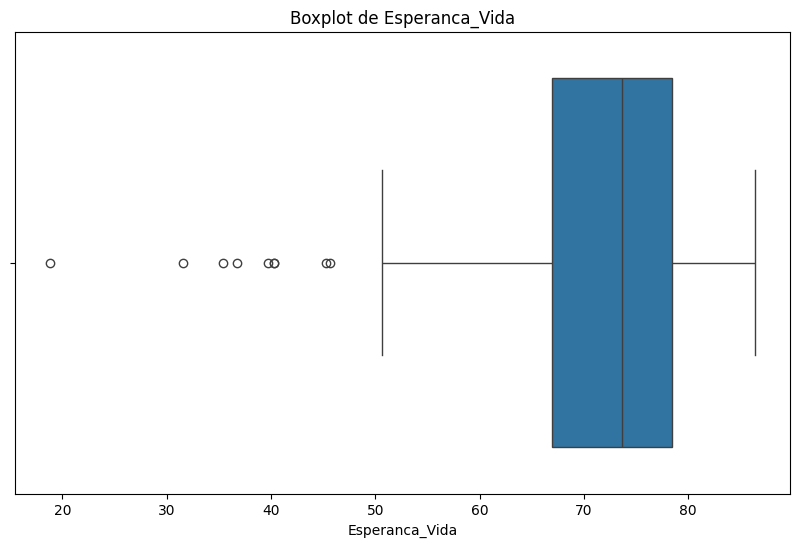

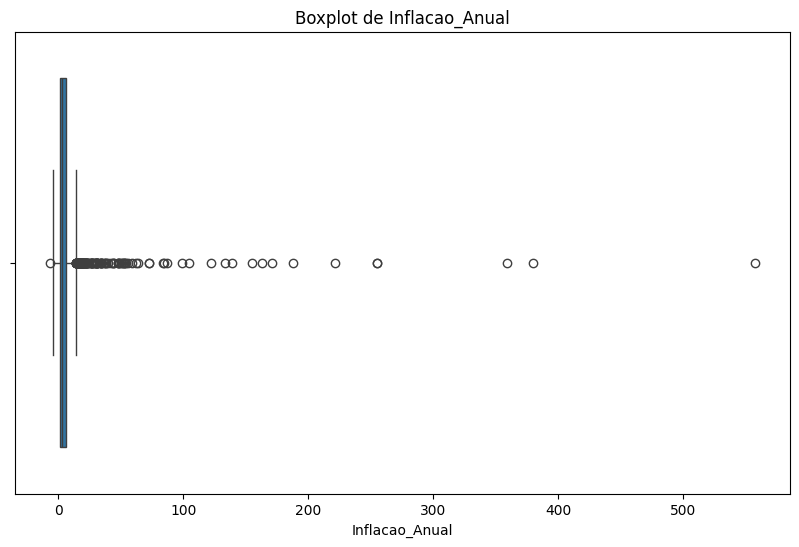

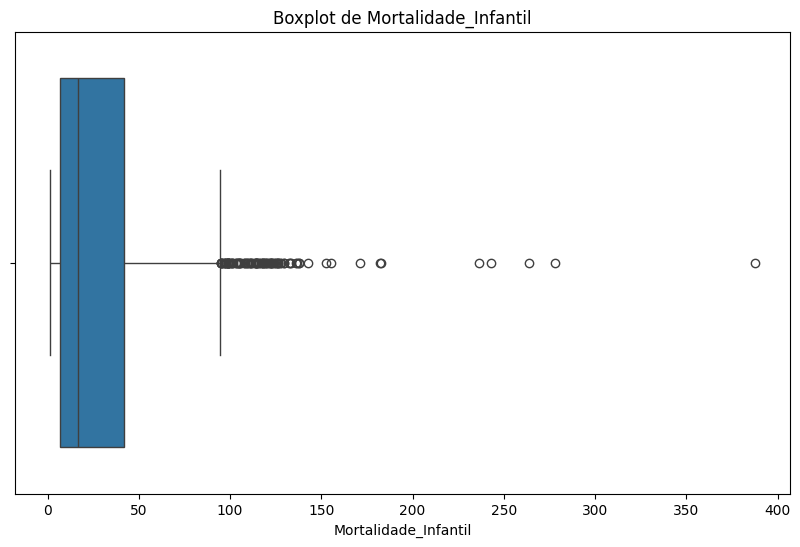

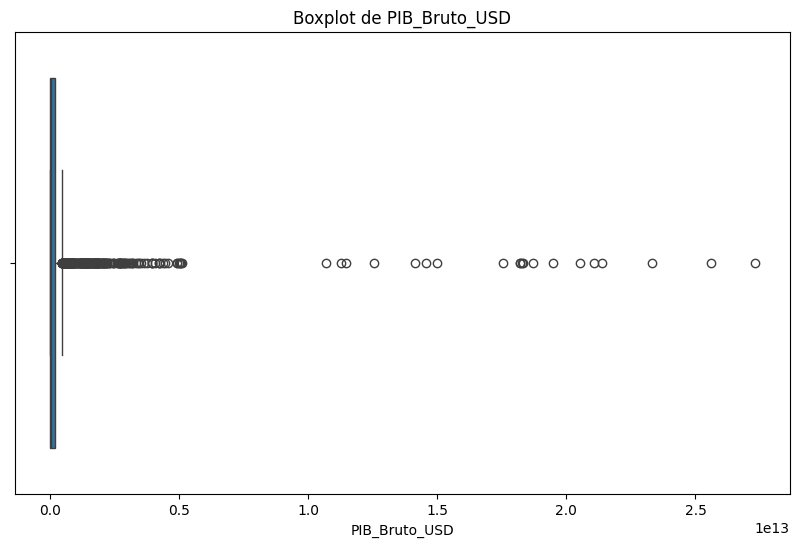

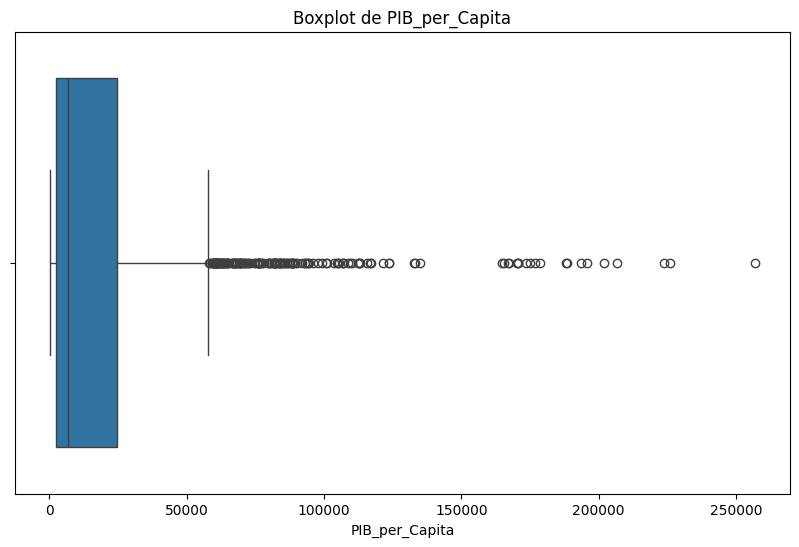

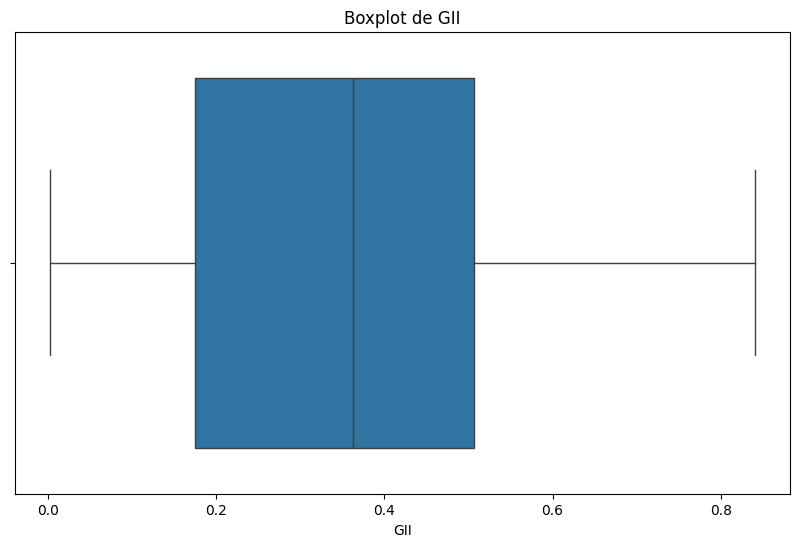

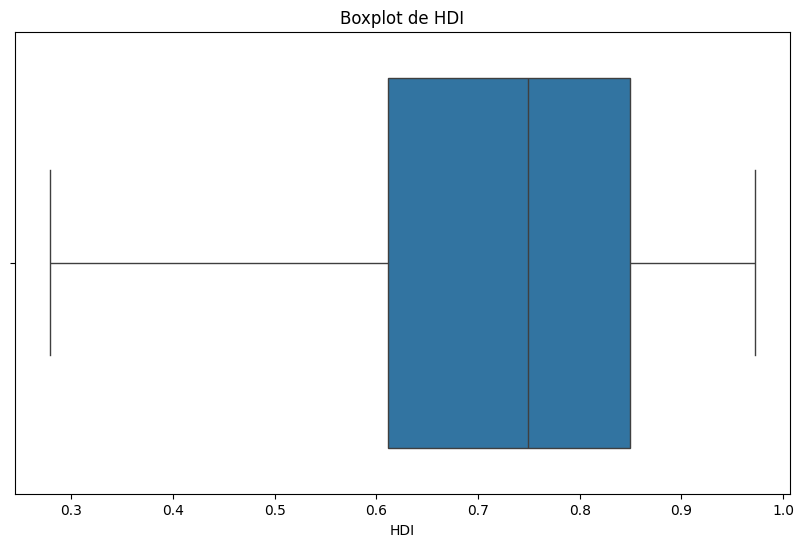

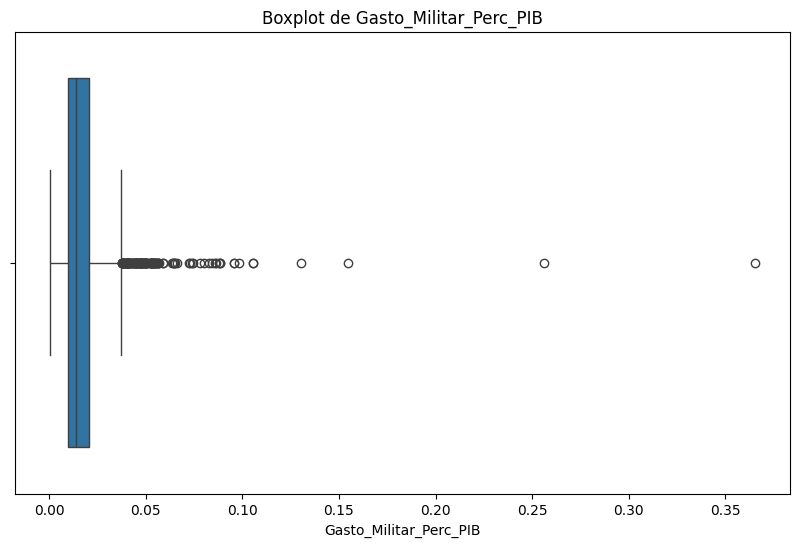

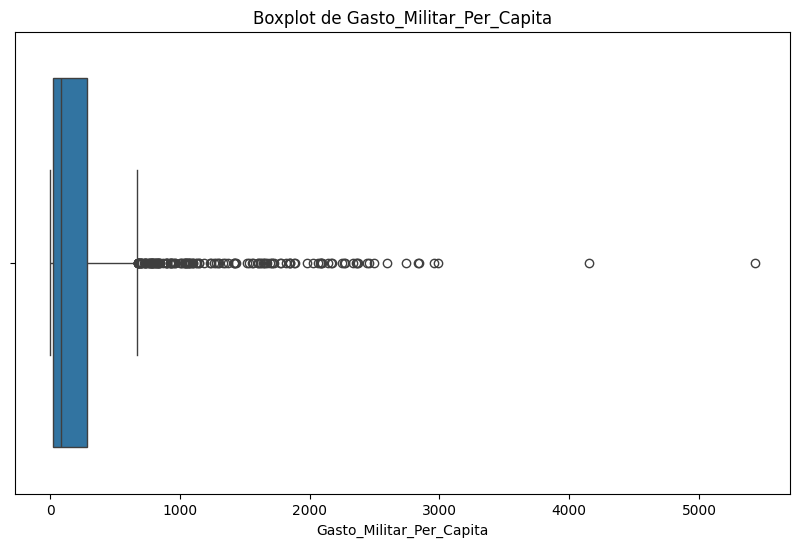

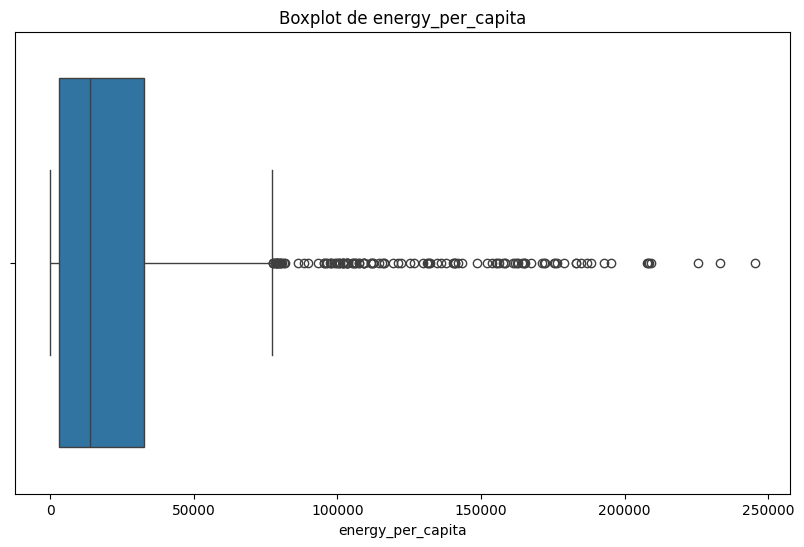

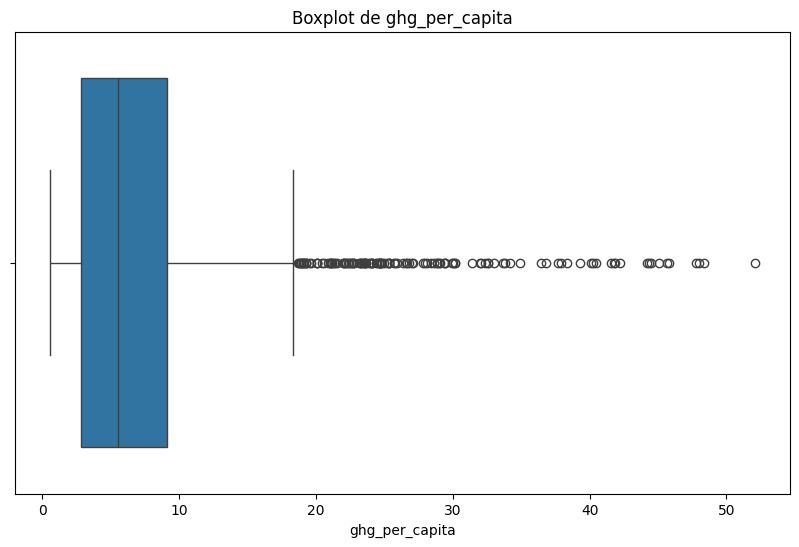

In [24]:
# Fazer boxplot de todas as features explicativas para verificar os outliers
features = ["Esperanca_Vida", "Inflacao_Anual", "Mortalidade_Infantil", "PIB_Bruto_USD", "PIB_per_Capita", "GII", "HDI",
            "Gasto_Militar_Perc_PIB", "Gasto_Militar_Per_Capita", "energy_per_capita", "ghg_per_capita"]

for feature in features:
    plt.figure(figsize=(10, 6))
    sns.boxplot(x=df_geral3[feature])
    plt.title(f'Boxplot de {feature}')
    plt.show()

In [25]:
# pouquíssimos outliers em esperança de vida
# Muitos outliers em Inflação anual, Mortalidade infantil, PIB bruto USD, PIB per capita, gasto militar em percentagem do pib, gasto militar per capita, energy per capita e ghg per capita
# Nenhum outlier em GII ou HDI

# Precisamos de considerar agora se esses outliers são outliers lógicos (contêm informação importante que não deve ser removida)
# Ou se são outliers que devem ser limpos.

In [26]:
# Para a esperança de vida, notamos alguns outliers que, embora poucos, são ridículos, nomeadamente um valor de esperança de vida de praticamente 19 anos de idade.
# Definiremos uma esperança de vida mínima, e se um valor estiver abaixo dessa esperança de vida será tratado como NaN
# Depois, corrigiremos esse valor omisso com a nossa futura função de remoção de outliers.
limite_minimo_vida = 45 # Já é muito, pois uma esperança de vida abaixo dos 50 anos, mesmo entre os países mais pobres, é considerado muito improvável.
outliers_vida = df_geral3[df_geral3['Esperanca_Vida'] < limite_minimo_vida]

print(f"Temos {len(outliers_vida)} casos impossíveis de Esperança de Vida.")
print(outliers_vida[['Country', 'Year', 'Esperanca_Vida']])

# Transformar esses outliers em NaN
df_geral3.loc[df_geral3['Esperanca_Vida'] < limite_minimo_vida, 'Esperanca_Vida'] = np.nan

Temos 7 casos impossíveis de Esperança de Vida.
                       Country  Year  Esperanca_Vida
310   Central African Republic  2014          40.265
315   Central African Republic  2019          31.530
317   Central African Republic  2021          40.279
318   Central African Republic  2022          18.818
1771               South Sudan  2015          39.757
1772               South Sudan  2016          36.720
1773               South Sudan  2017          35.351


In [27]:
# De acordo com investigação online, e com recurso a Agentes de Inteligência Artificial, descobrimos que outliers em variáveis financeiras costumam ser tratados por transformação
# Em específico, transformação logaritmica. Portanto, transformaremos todas as nossas variáveis financeiras não percentuais através de log.
print(df_geral3.eq(0).sum())
# Usaremos log(1+x) porque uma das features têm alguns valores iguais a zero. Assim, não temos problemas com essa feature.
cols_log = ['PIB_Bruto_USD', 'PIB_per_Capita', 'Gasto_Militar_Per_Capita', 'energy_per_capita', 'ghg_per_capita']
for col in cols_log:
    # Criamos uma nova coluna para manter a original intacta, se quisermos ver valores específicos
    # Por exemplo, se quisermos ver o PIB per capita específico ao invés apenas de qual o país com maior PIB
    df_geral3[f'{col}_log'] = np.log1p(df_geral3[col])
display(df_geral3)

economy                      0
Country                      0
Year                         0
Esperanca_Vida               0
Inflacao_Anual               0
Mortalidade_Infantil         0
PIB_Bruto_USD                0
PIB_per_Capita               0
GII                          0
HDI                          0
Gasto_Militar_Perc_PIB       0
Gasto_Militar_Per_Capita     0
energy_per_capita           10
ghg_per_capita               0
dtype: int64


,economy,Country,Year,Esperanca_Vida,Inflacao_Anual,Mortalidade_Infantil,PIB_Bruto_USD,PIB_per_Capita,GII,HDI,Gasto_Militar_Perc_PIB,Gasto_Militar_Per_Capita,energy_per_capita,ghg_per_capita,PIB_Bruto_USD_log,PIB_per_Capita_log,Gasto_Militar_Per_Capita_log,energy_per_capita_log,ghg_per_capita_log
0,ABW,Aruba,2014,75.261,0.421441,NaN,2.790850e+09,26129.839062,NaN,NaN,NaN,NaN,47990.925781,8.717759,21.749612,10.170871,NaN,10.778788,2.273955
1,ABW,Aruba,2015,75.405,0.474764,NaN,2.962907e+09,27458.220154,NaN,NaN,NaN,NaN,48905.531250,8.897266,21.809437,10.220457,NaN,10.797666,2.292259
2,ABW,Aruba,2016,75.540,-0.931196,NaN,2.983637e+09,27441.550214,NaN,NaN,NaN,NaN,47619.417969,8.697294,21.816409,10.219850,NaN,10.771017,2.271847
3,ABW,Aruba,2017,75.620,-1.028282,NaN,3.092428e+09,28440.041688,NaN,NaN,NaN,NaN,49061.195312,8.704082,21.852222,10.255589,NaN,10.800844,2.272547
4,ABW,Aruba,2018,75.880,3.626041,NaN,3.276188e+09,30082.158423,NaN,NaN,NaN,NaN,46080.550781,8.440516,21.909946,10.311721,NaN,10.738168,2.245011
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2165,ZWE,Zimbabwe,2019,61.060,255.304991,51.1,3.335770e+10,2184.329239,0.525,0.584,0.006531,36.103967,2603.881104,2.008451,24.230554,7.689522,3.613724,7.865142,1.101425
2166,ZWE,Zimbabwe,2020,61.530,557.201817,50.1,3.198033e+10,2059.674454,0.519,0.582,0.009750,15.732077,2163.068359,1.555098,24.188387,7.630789,2.817328,7.679745,0.938091
2167,ZWE,Zimbabwe,2021,60.135,98.546105,47.6,4.128767e+10,2613.605421,0.519,0.581,0.015678,30.264705,2382.434326,1.766547,24.443830,7.868868,3.442490,7.776298,1.017600
2168,ZWE,Zimbabwe,2022,62.360,104.705171,46.0,4.075756e+10,2536.400502,0.520,0.594,0.009950,20.879657,3633.067383,1.861766,24.430907,7.838895,3.085557,8.198108,1.051439


In [28]:
# Para variáveis percentuais (ou taxas, como mortalidade infantil que conta número de mortes juvenis entre 1000 crianças) usaremos a técnica de capping
# Ou seja, definimos um limite através de um certo quartil (neste caso testaremos 99%), e qualquer valor que ultrapasse esse limite passa a ser o próprio limite
# Tentamos 95%, mas achamos bastante agressivo.
cols_cap = ['Inflacao_Anual', 'Mortalidade_Infantil', 'Gasto_Militar_Perc_PIB']

for col in cols_cap:
    limite_superior = df_geral3[col].quantile(0.99)
    df_geral3[col] = df_geral3[col].clip(upper=limite_superior)
    # Para o capping já não definimos uma coluna extra, pois não fazemos mudança na 'ordem' da variável, então não precisamos de criar features extra.


In [29]:
# Contagem de valores omissos por coluna
print("Valores nulos por coluna:")
print(df_geral3.isnull().sum())
# Inflação Anual, Mortalidade Infantil, PIB per capita, GII e HDI têm valores omissos

Valores nulos por coluna:
economy                           0
Country                           0
Year                              0
Esperanca_Vida                    7
Inflacao_Anual                  342
Mortalidade_Infantil            210
PIB_Bruto_USD                    69
PIB_per_Capita                   69
GII                             508
HDI                             249
Gasto_Militar_Perc_PIB          791
Gasto_Militar_Per_Capita        791
energy_per_capita               460
ghg_per_capita                  490
PIB_Bruto_USD_log                69
PIB_per_Capita_log               69
Gasto_Militar_Per_Capita_log    791
energy_per_capita_log           460
ghg_per_capita_log              490
dtype: int64


In [30]:
# Como temos uma base de dados em que cada entrada é 'agrupada' (cada país têm 10 entradas para cada ano), achamos correto medir os valores omissos por grupo.
# Assim, podemos ver que economias possuem valores omissos, e se existem economias com valores omissos por completo
missing_values_by_economy = df_geral3.groupby('economy').apply(lambda x: x.isnull().sum())
missing_values_by_economy = missing_values_by_economy.drop(columns=['economy', 'country', 'Year'], errors='ignore') # Ignorar as colunas de index (não têm valores omissos)
# Filtrar apenas as economias que têm valores nulos em alguma coluna
economies_with_any_missing = missing_values_by_economy[missing_values_by_economy.sum(axis=1) > 0]
print(economies_with_any_missing)

# Identificar economias com 10 valores nulos por coluna (economias totalmente omissas)
economies_with_10_missing_in_column = []
columns_to_check = ['Inflacao_Anual', 'Mortalidade_Infantil', 'PIB_Bruto_USD', 'PIB_per_Capita',
                    'GII', 'HDI', 'Gasto_Militar_Perc_PIB', 'Gasto_Militar_Per_Capita',
                    'energy_per_capita', 'ghg_per_capita']

for economy, row_data in economies_with_any_missing.iterrows():
    for col in columns_to_check:
        if col in row_data.index and row_data[col] == 10:
            economies_with_10_missing_in_column.append({'economy': economy, 'column': col, 'missing_count': 10})

if economies_with_10_missing_in_column:
    for item in economies_with_10_missing_in_column:
        print(f"  Economia: {item['economy']}, Coluna: {item['column']}, Contagem de nulos: {item['missing_count']}")
else:
    print("  Nenhuma economia encontrada com exatamente 10 valores nulos em uma única coluna.")

         Country  Esperanca_Vida  Inflacao_Anual  Mortalidade_Infantil  \
economy                                                                  
ABW            0               0               4                    10   
AFG            0               0               0                     0   
AND            0               0              10                     0   
ARE            0               0               0                     0   
ARG            0               0               4                     0   
...          ...             ...             ...                   ...   
VUT            0               0               0                     0   
WSM            0               0               0                     0   
XKX            0               0               0                     0   
YEM            0               0               9                     0   
ZWE            0               0               1                     0   

         PIB_Bruto_USD  PIB_per_Capit

/tmp/ipython-input-3435083390.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  missing_values_by_economy = df_geral3.groupby('economy').apply(lambda x: x.isnull().sum())


/tmp/ipython-input-2081579585.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=missing_counts_distribution.index, y=missing_counts_distribution.values, palette='viridis')


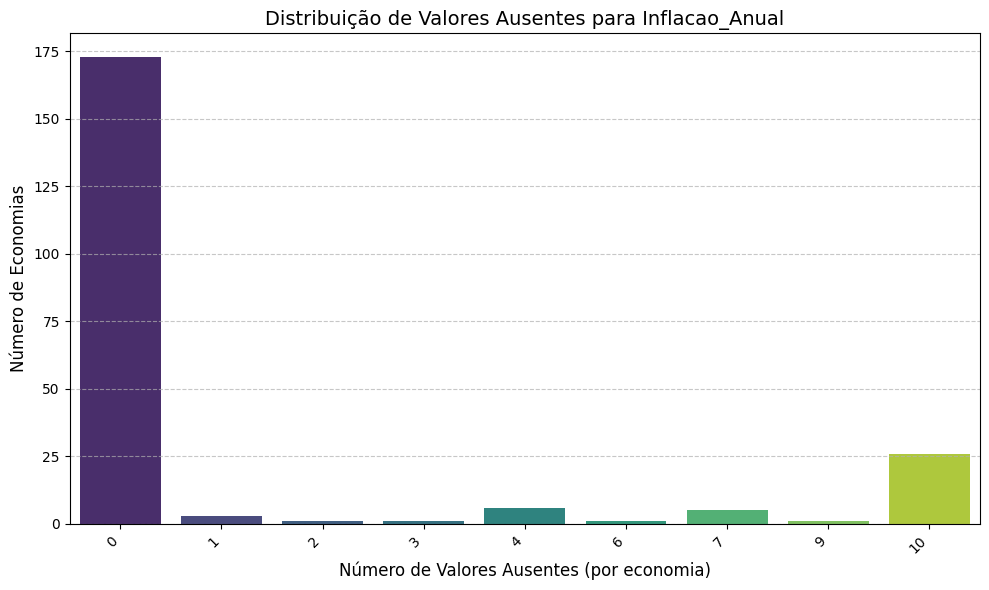

/tmp/ipython-input-2081579585.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=missing_counts_distribution.index, y=missing_counts_distribution.values, palette='viridis')


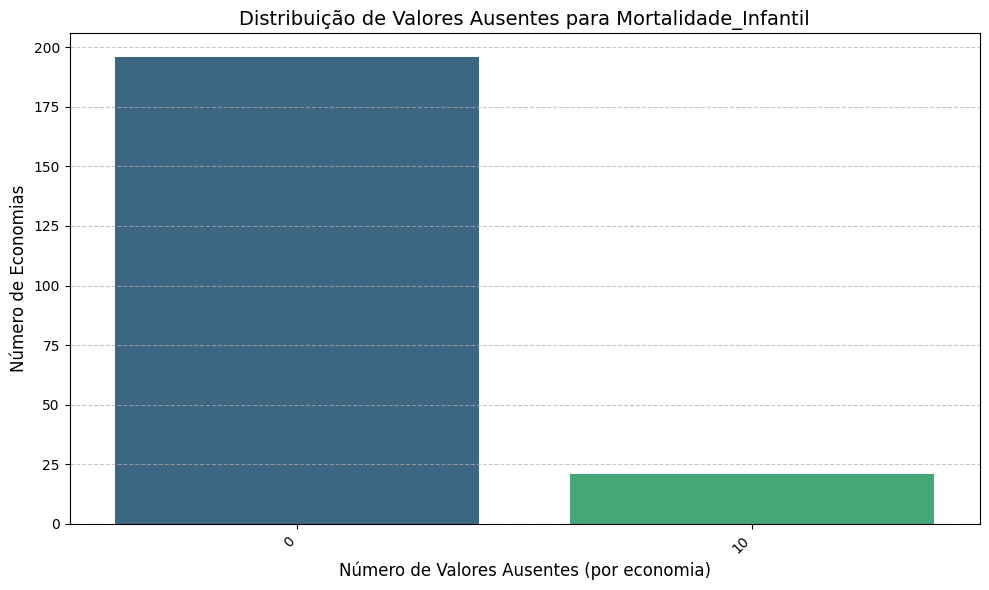

/tmp/ipython-input-2081579585.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=missing_counts_distribution.index, y=missing_counts_distribution.values, palette='viridis')


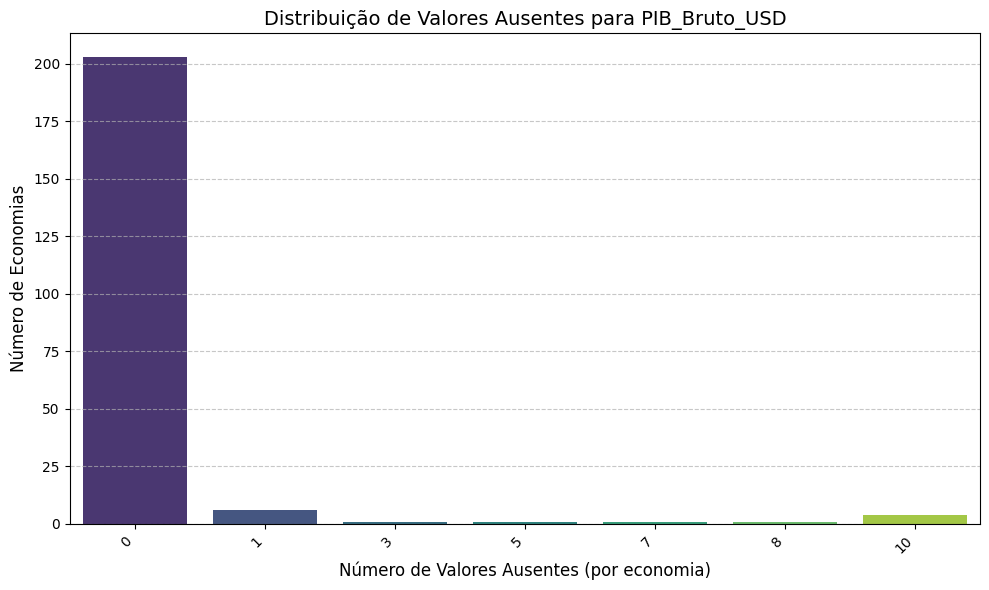

/tmp/ipython-input-2081579585.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=missing_counts_distribution.index, y=missing_counts_distribution.values, palette='viridis')


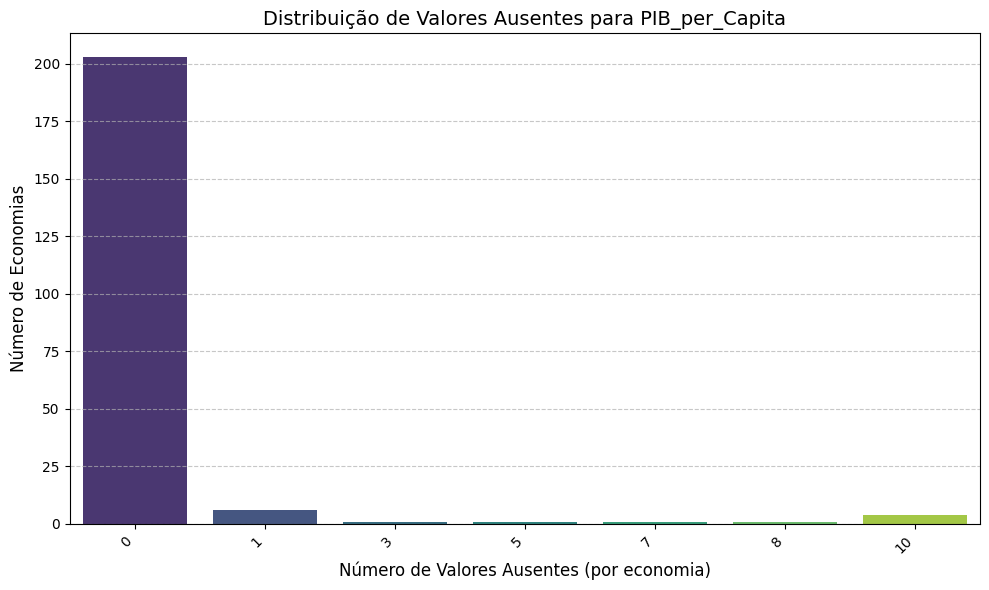

/tmp/ipython-input-2081579585.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=missing_counts_distribution.index, y=missing_counts_distribution.values, palette='viridis')


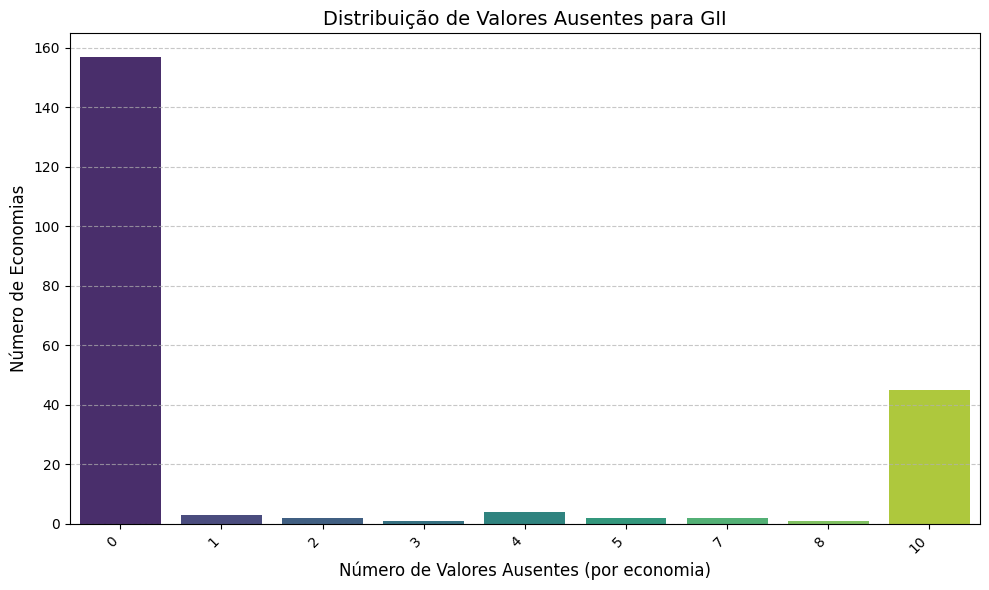

/tmp/ipython-input-2081579585.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=missing_counts_distribution.index, y=missing_counts_distribution.values, palette='viridis')


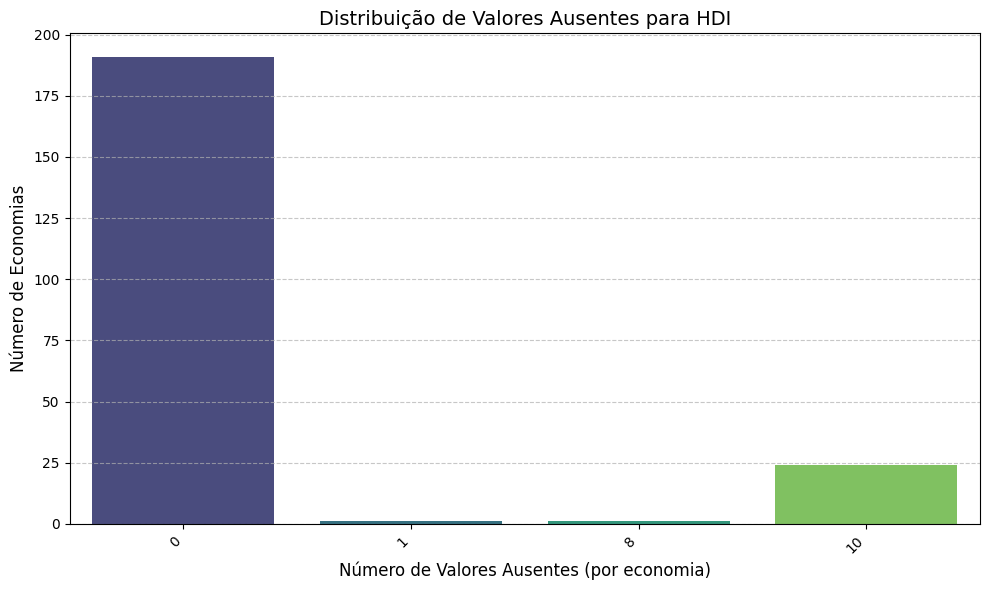

/tmp/ipython-input-2081579585.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=missing_counts_distribution.index, y=missing_counts_distribution.values, palette='viridis')


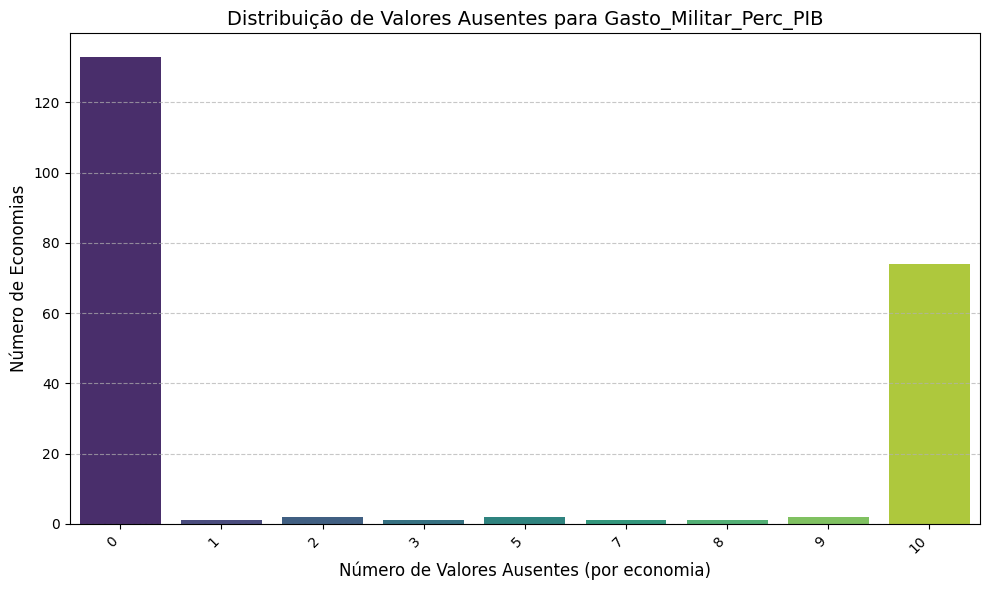

/tmp/ipython-input-2081579585.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=missing_counts_distribution.index, y=missing_counts_distribution.values, palette='viridis')


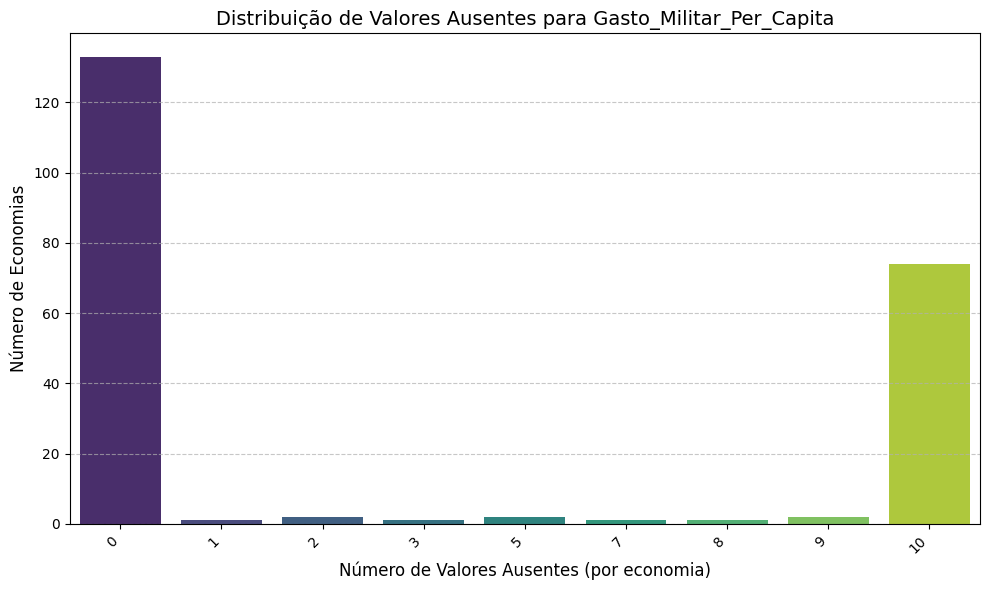

/tmp/ipython-input-2081579585.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=missing_counts_distribution.index, y=missing_counts_distribution.values, palette='viridis')


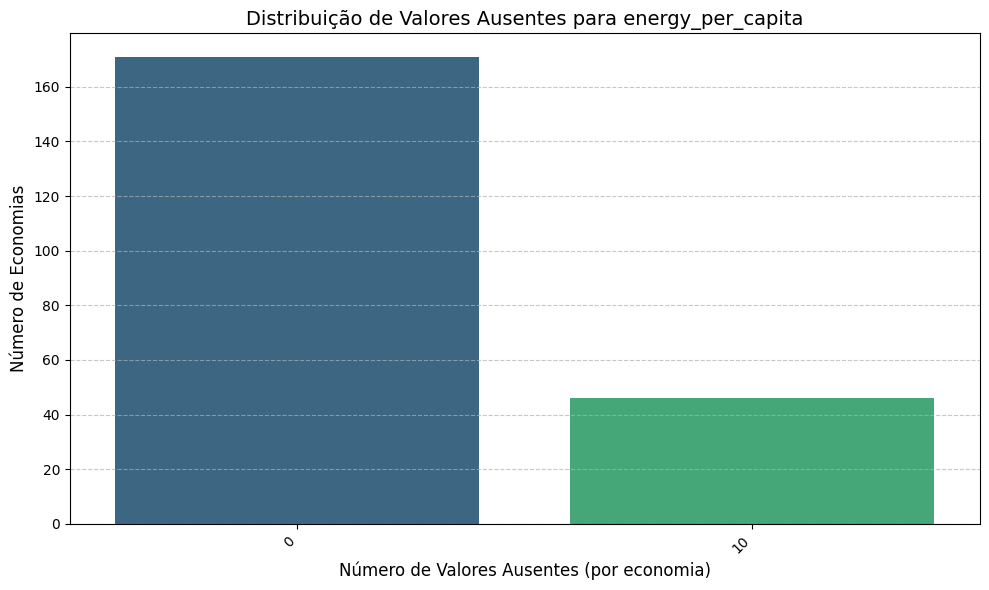

/tmp/ipython-input-2081579585.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=missing_counts_distribution.index, y=missing_counts_distribution.values, palette='viridis')


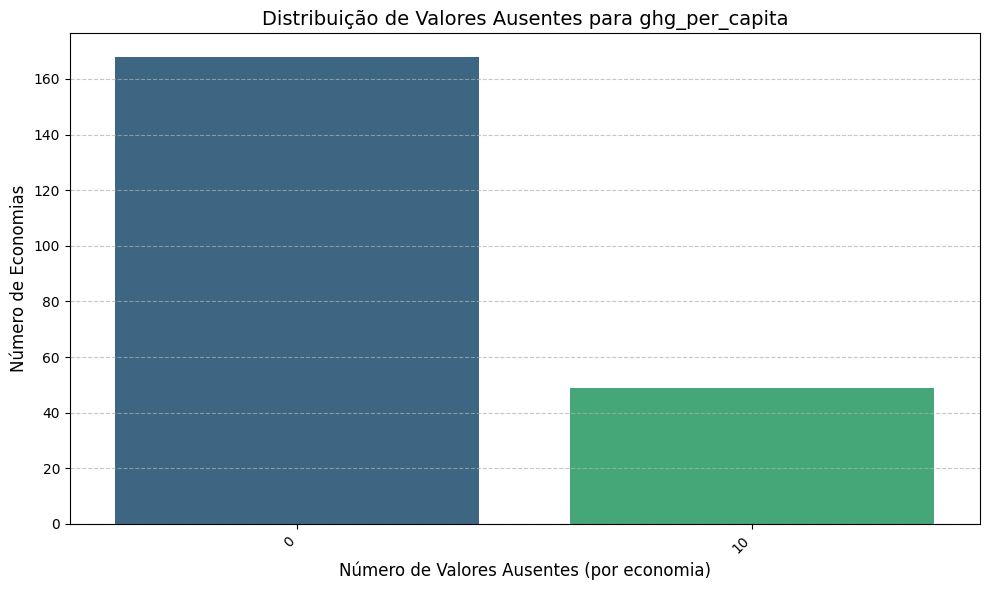

In [31]:
# Gerar gráficos de barras para a distribuição de valores omissos por coluna
for col in columns_to_check:
    if col in missing_values_by_economy.columns:
        # Obter a distribuição da contagem de valores omissos para a coluna atual
        missing_counts_distribution = missing_values_by_economy[col].value_counts().sort_index()

        if not missing_counts_distribution.empty:
            plt.figure(figsize=(10, 6))
            sns.barplot(x=missing_counts_distribution.index, y=missing_counts_distribution.values, palette='viridis')
            plt.title(f'Distribuição de Valores Ausentes para {col}', fontsize=14)
            plt.xlabel('Número de Valores Ausentes (por economia)', fontsize=12)
            plt.ylabel('Número de Economias', fontsize=12)
            plt.xticks(rotation=45, ha='right')
            plt.grid(axis='y', linestyle='--', alpha=0.7)
            plt.tight_layout()
            plt.show()
        else:
            print(f"  Não há valores ausentes para {col} ou dados suficientes para plotar.")
    else:
        print(f"  Coluna '{col}' não encontrada na análise de valores omissos por economia.")

In [32]:
# Como podemos ver, temos várias economias com todos os valores de pelo menos uma das features omissos
# Um dos motivos deve-se ao left join entre as bases de dados, pois o World Bank possui cerca de 266 entidades enquanto o HDR têm 195 entidades apenas, por exemplo.
# Portanto, temos que descobrir como limpar esses valores omissos.
# Remoção de linhas, neste caso, não é uma opção correta pois estaremos a perder informação importante de cada país.
# Temos que preencher os valores omissos.

# Uma ideia é, no caso de valores omissos, verificar quantos valores omissos são:
# Se forem menos de 10, os valores omissos em falta dessa economia são calculados pela média dos valores dessa feature nessa economia dos outros anos.
# Se forem 10, os valores omissos em falta dessa economia são calculados pela média da região.
# Existe, portanto, que determinar o que usamos como região.
# Uma vez que o World Bank já têm uma feature 'incomeLevel' (Low Income, Lower Middle Income, Upper Middle Income, High Income), podemos usá-lo como região
# E, assim, temos o necessário para preencher os valores omissos

In [33]:
# Obter os grupos de rendimento do Banco Mundial
economy_metadata = wb.economy.DataFrame()[['incomeLevel']]
df_geral3 = df_geral3.merge(economy_metadata, left_on='economy', right_index=True, how='left')
# Verificar se a nova coluna têm valores omissos
print(df_geral3['incomeLevel'].isnull().sum())

0


In [34]:
# Explicando novamente a nossa função de limpeza de valores omissos:
# Verificar, para cada economia, quantos valores omissos de certa feature existem.
# Se forem menos de 10, preencher valores omissos com a média dos valores da feature dessa economia.
# Se forem igual a 10, preencher valores omissos com a média dos valores da feature das economias que partilham o mesmo incomeLevel
def tratar_valores_omissos(df):
    # Definir as colunas numéricas que precisam de tratamento
    colunas_features = [
        'Inflacao_Anual', 'Esperanca_Vida', 'Mortalidade_Infantil', 'PIB_Bruto_USD', 'PIB_per_Capita',
        'GII', 'HDI', 'Gasto_Militar_Perc_PIB', 'Gasto_Militar_Per_Capita', 'energy_per_capita',
        'ghg_per_capita', 'PIB_Bruto_USD_log', 'PIB_per_Capita_log', 'Gasto_Militar_Per_Capita_log',
        'energy_per_capita_log', 'ghg_per_capita_log'
    ]

    # Criar uma cópia para não alterar o dataframe original
    df_clean = df.copy()

    for col in colunas_features:
        if col not in df_clean.columns:
            continue

        # Preencher pela média do País (Economia)
        # Se o país tiver entre 1 a 9 valores presentes, o transform('mean') calculará a média desses valores e o fillna aplicará apenas nos buracos.
        # Se o país tiver os 10 valores nulos, a média será NaN ainda, então nada mudará aqui.
        df_clean[col] = df_clean[col].fillna(
            df_clean.groupby('economy')[col].transform('mean')
        )

        # Preencher pela média do Income Level
        # Para os casos que continuam nulos usamos a média do grupo de rendimento.
        # Agrupamos por incomeLevel E Year para usar apenas os níveis de cada ano para calcular a média
        # De modo a manter tendências em casos de situações globais (como crises)
        df_clean[col] = df_clean[col].fillna(
            df_clean.groupby(['incomeLevel', 'Year'])[col].transform('mean')
        )

    return df_clean

In [35]:
df_final = tratar_valores_omissos(df_geral3)

In [36]:
# Verificação
print("Valores nulos após tratamento:")
print(df_final.isnull().sum())

Valores nulos após tratamento:
economy                         0
Country                         0
Year                            0
Esperanca_Vida                  0
Inflacao_Anual                  0
Mortalidade_Infantil            0
PIB_Bruto_USD                   0
PIB_per_Capita                  0
GII                             0
HDI                             0
Gasto_Militar_Perc_PIB          0
Gasto_Militar_Per_Capita        0
energy_per_capita               0
ghg_per_capita                  0
PIB_Bruto_USD_log               0
PIB_per_Capita_log              0
Gasto_Militar_Per_Capita_log    0
energy_per_capita_log           0
ghg_per_capita_log              0
incomeLevel                     0
dtype: int64


In [37]:
# Criar uma feature para o "Nível de HDI", para estudarmos a variação de cada economia no seu HDI ao longo do tempo de forma categórica
# Definimos a feature através dos quartis do HDI. Assim temos uma espécie de "comparação" entre esse país e os outros.
# Usaremos a técnica do Equal Width para a discretização
# Definir os limites dos quartis
hdi_quantiles = df_final['HDI'].quantile([0.25, 0.50, 0.75])
Q1 = hdi_quantiles[0.25]
Q2 = hdi_quantiles[0.50]
Q3 = hdi_quantiles[0.75]

# Definir os bins e os labels
bins = [df_final['HDI'].min() - 1, Q1, Q2, Q3, df_final['HDI'].max() + 1]
labels = ['HDI baixo', 'HDI mediano', 'HDI alto', 'HDI muito alto']

# Criar a nova coluna categórica 'Nível de HDI'
df_final['Nível_de_HDI'] = pd.cut(df_final['HDI'], bins=bins, labels=labels, right=True)
display(df_final)
# Podemos notar que o nível de HDI pode mudar de ano para ano.

,economy,Country,Year,Esperanca_Vida,Inflacao_Anual,Mortalidade_Infantil,PIB_Bruto_USD,PIB_per_Capita,GII,HDI,...,Gasto_Militar_Per_Capita,energy_per_capita,ghg_per_capita,PIB_Bruto_USD_log,PIB_per_Capita_log,Gasto_Militar_Per_Capita_log,energy_per_capita_log,ghg_per_capita_log,incomeLevel,Nível_de_HDI
0,ABW,Aruba,2014,75.261,0.421441,7.510769,2.790850e+09,26129.839062,0.181599,0.872875,...,774.576509,47990.925781,8.717759,21.749612,10.170871,6.154234,10.778788,2.273955,HIC,HDI alto
1,ABW,Aruba,2015,75.405,0.474764,7.349231,2.962907e+09,27458.220154,0.176385,0.875938,...,716.338642,48905.531250,8.897266,21.809437,10.220457,6.047081,10.797666,2.292259,HIC,HDI alto
2,ABW,Aruba,2016,75.540,-0.931196,7.180000,2.983637e+09,27441.550214,0.172396,0.879141,...,712.429192,47619.417969,8.697294,21.816409,10.219850,6.083944,10.771017,2.271847,HIC,HDI alto
3,ABW,Aruba,2017,75.620,-1.028282,7.020000,3.092428e+09,28440.041688,0.156682,0.882594,...,737.033915,49061.195312,8.704082,21.852222,10.255589,6.150499,10.800844,2.272547,HIC,HDI muito alto
4,ABW,Aruba,2018,75.880,3.626041,6.864615,3.276188e+09,30082.158423,0.150226,0.885703,...,776.941054,46080.550781,8.440516,21.909946,10.311721,6.232419,10.738168,2.245011,HIC,HDI muito alto
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2165,ZWE,Zimbabwe,2019,61.060,72.397839,51.100000,3.335770e+10,2184.329239,0.525000,0.584000,...,36.103967,2603.881104,2.008451,24.230554,7.689522,3.613724,7.865142,1.101425,LMC,HDI baixo
2166,ZWE,Zimbabwe,2020,61.530,72.397839,50.100000,3.198033e+10,2059.674454,0.519000,0.582000,...,15.732077,2163.068359,1.555098,24.188387,7.630789,2.817328,7.679745,0.938091,LMC,HDI baixo
2167,ZWE,Zimbabwe,2021,60.135,72.397839,47.600000,4.128767e+10,2613.605421,0.519000,0.581000,...,30.264705,2382.434326,1.766547,24.443830,7.868868,3.442490,7.776298,1.017600,LMC,HDI baixo
2168,ZWE,Zimbabwe,2022,62.360,72.397839,46.000000,4.075756e+10,2536.400502,0.520000,0.594000,...,20.879657,3633.067383,1.861766,24.430907,7.838895,3.085557,8.198108,1.051439,LMC,HDI baixo


In [38]:
df_final.info()
# Temos, portanto, apenas variáveis numéricas exceto economy, Country, incomeLevel e Nível de HDI
# Contudo, incomeLevel surge como object, o que não é tão ótimo considerando que possui apenas quatro categorias

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2170 entries, 0 to 2169
Data columns (total 21 columns):
 #   Column                        Non-Null Count  Dtype   
---  ------                        --------------  -----   
 0   economy                       2170 non-null   object  
 1   Country                       2170 non-null   object  
 2   Year                          2170 non-null   int64   
 3   Esperanca_Vida                2170 non-null   float64 
 4   Inflacao_Anual                2170 non-null   float64 
 5   Mortalidade_Infantil          2170 non-null   float64 
 6   PIB_Bruto_USD                 2170 non-null   float64 
 7   PIB_per_Capita                2170 non-null   float64 
 8   GII                           2170 non-null   float64 
 9   HDI                           2170 non-null   float64 
 10  Gasto_Militar_Perc_PIB        2170 non-null   float64 
 11  Gasto_Militar_Per_Capita      2170 non-null   float64 
 12  energy_per_capita             2170 non-null   fl

In [39]:
# Tornar incomeLevel em uma variável categórica ao invés de object
df_final['incomeLevel'] = df_final['incomeLevel'].astype('category')

In [40]:
# Criar uma coluna para o Score Socioeconómico Composto
# Vale-se ressaltar que decidimos definir o score socioeconómico composto como a média de TODAS as colunas.
feature_cols = [
    'Esperanca_Vida',
    'Inflacao_Anual',
    'Mortalidade_Infantil',
    'PIB_per_Capita_log',
    'GII',
    'HDI',
    'Gasto_Militar_Perc_PIB',
    'Gasto_Militar_Per_Capita_log',
    'energy_per_capita_log',
    'ghg_per_capita_log'
]

# Inicializar o Scaler
scaler = MinMaxScaler()

In [41]:
# Criar um dataframe para as features ajustadas
# Não deixaremos isto no nosso dataframe original porque não queremos realmente ajustar todas as features
# Afinal, algumas devem ser mantidas como estão, como o GII e o HDI (que já estão entre 0 e 1)
df_final_scaled = df_final.copy()
df_final_scaled[feature_cols] = scaler.fit_transform(df_final_scaled[feature_cols])

# Inverter escalas dos valores para GII, Mortalidade infantil e Inflação Anual
df_final_scaled['GII'] = -1 * df_final_scaled['GII']
df_final_scaled['Mortalidade_Infantil'] = -1 * df_final_scaled['Mortalidade_Infantil']
df_final_scaled['Inflacao_Anual'] = -1 * df_final_scaled['Inflacao_Anual']
df_final_scaled['ghg_per_capita'] = -1 * df_final_scaled['ghg_per_capita']
display(df_final_scaled.head())

,economy,Country,Year,Esperanca_Vida,Inflacao_Anual,Mortalidade_Infantil,PIB_Bruto_USD,PIB_per_Capita,GII,HDI,...,Gasto_Militar_Per_Capita,energy_per_capita,ghg_per_capita,PIB_Bruto_USD_log,PIB_per_Capita_log,Gasto_Militar_Per_Capita_log,energy_per_capita_log,ghg_per_capita_log,incomeLevel,Nível_de_HDI
0,ABW,Aruba,2014,0.729929,-0.089887,-0.048088,2.790850e+09,26129.839062,-0.213380,0.856962,...,774.576509,47990.925781,-8.717759,21.749612,0.673592,0.701222,0.868541,0.517711,HIC,HDI alto
1,ABW,Aruba,2015,0.733429,-0.090562,-0.046817,2.962907e+09,27458.220154,-0.207150,0.861382,...,716.338642,48905.531250,-8.897266,21.809437,0.680674,0.688130,0.870062,0.522911,HIC,HDI alto
2,ABW,Aruba,2016,0.736710,-0.072784,-0.045485,2.983637e+09,27441.550214,-0.202385,0.866004,...,712.429192,47619.417969,-8.697294,21.816409,0.680588,0.692634,0.867915,0.517112,HIC,HDI alto
3,ABW,Aruba,2017,0.738655,-0.071556,-0.044226,3.092428e+09,28440.041688,-0.183610,0.870987,...,737.033915,49061.195312,-8.704082,21.852222,0.685692,0.700766,0.870318,0.517310,HIC,HDI muito alto
4,ABW,Aruba,2018,0.744975,-0.130408,-0.043003,3.276188e+09,30082.158423,-0.175897,0.875473,...,776.941054,46080.550781,-8.440516,21.909946,0.693710,0.710775,0.865268,0.509487,HIC,HDI muito alto


In [42]:
# Definir a coluna Score socioeconomico Composto como a média de todas as outras features
df_final_scaled['Score_Socioeconomico_Composto'] = df_final_scaled[feature_cols].mean(axis=1)
display(df_final_scaled.head())

,economy,Country,Year,Esperanca_Vida,Inflacao_Anual,Mortalidade_Infantil,PIB_Bruto_USD,PIB_per_Capita,GII,HDI,...,energy_per_capita,ghg_per_capita,PIB_Bruto_USD_log,PIB_per_Capita_log,Gasto_Militar_Per_Capita_log,energy_per_capita_log,ghg_per_capita_log,incomeLevel,Nível_de_HDI,Score_Socioeconomico_Composto
0,ABW,Aruba,2014,0.729929,-0.089887,-0.048088,2.790850e+09,26129.839062,-0.213380,0.856962,...,47990.925781,-8.717759,21.749612,0.673592,0.701222,0.868541,0.517711,HIC,HDI alto,0.423476
1,ABW,Aruba,2015,0.733429,-0.090562,-0.046817,2.962907e+09,27458.220154,-0.207150,0.861382,...,48905.531250,-8.897266,21.809437,0.680674,0.688130,0.870062,0.522911,HIC,HDI alto,0.425380
2,ABW,Aruba,2016,0.736710,-0.072784,-0.045485,2.983637e+09,27441.550214,-0.202385,0.866004,...,47619.417969,-8.697294,21.816409,0.680588,0.692634,0.867915,0.517112,HIC,HDI alto,0.428817
3,ABW,Aruba,2017,0.738655,-0.071556,-0.044226,3.092428e+09,28440.041688,-0.183610,0.870987,...,49061.195312,-8.704082,21.852222,0.685692,0.700766,0.870318,0.517310,HIC,HDI muito alto,0.433245
4,ABW,Aruba,2018,0.744975,-0.130408,-0.043003,3.276188e+09,30082.158423,-0.175897,0.875473,...,46080.550781,-8.440516,21.909946,0.693710,0.710775,0.865268,0.509487,HIC,HDI muito alto,0.429924


In [43]:
# Adicionar o Score socioeconomico composto ao nosso dataframe
df_final['Score_Socioeconomico_Composto'] = df_final_scaled['Score_Socioeconomico_Composto']
display(df_final.head())

,economy,Country,Year,Esperanca_Vida,Inflacao_Anual,Mortalidade_Infantil,PIB_Bruto_USD,PIB_per_Capita,GII,HDI,...,energy_per_capita,ghg_per_capita,PIB_Bruto_USD_log,PIB_per_Capita_log,Gasto_Militar_Per_Capita_log,energy_per_capita_log,ghg_per_capita_log,incomeLevel,Nível_de_HDI,Score_Socioeconomico_Composto
0,ABW,Aruba,2014,75.261,0.421441,7.510769,2.790850e+09,26129.839062,0.181599,0.872875,...,47990.925781,8.717759,21.749612,10.170871,6.154234,10.778788,2.273955,HIC,HDI alto,0.423476
1,ABW,Aruba,2015,75.405,0.474764,7.349231,2.962907e+09,27458.220154,0.176385,0.875938,...,48905.531250,8.897266,21.809437,10.220457,6.047081,10.797666,2.292259,HIC,HDI alto,0.425380
2,ABW,Aruba,2016,75.540,-0.931196,7.180000,2.983637e+09,27441.550214,0.172396,0.879141,...,47619.417969,8.697294,21.816409,10.219850,6.083944,10.771017,2.271847,HIC,HDI alto,0.428817
3,ABW,Aruba,2017,75.620,-1.028282,7.020000,3.092428e+09,28440.041688,0.156682,0.882594,...,49061.195312,8.704082,21.852222,10.255589,6.150499,10.800844,2.272547,HIC,HDI muito alto,0.433245
4,ABW,Aruba,2018,75.880,3.626041,6.864615,3.276188e+09,30082.158423,0.150226,0.885703,...,46080.550781,8.440516,21.909946,10.311721,6.232419,10.738168,2.245011,HIC,HDI muito alto,0.429924


In [44]:
# Análise Exploratória

In [45]:
# Qual o país com maior esperança de vida:
pais_maior_esperanca_vida = df_final['Country'].loc[df_final['Esperanca_Vida'].idxmax()]
print(f"O país com a maior esperança de vida é: {pais_maior_esperanca_vida}")

O país com a maior esperança de vida é: Monaco


In [46]:
# Qual o país com menor mortalidade infantil:
pais_menor_mortalidade_infantil = df_final['Country'].loc[df_final['Mortalidade_Infantil'].idxmin()]
print(f"O país com a menor mortalidade infantil é: {pais_menor_mortalidade_infantil}")

O país com a menor mortalidade infantil é: San Marino


In [47]:
# Qual o país com maior inflação média anual nos últimos 10 anos:

# Calcular a média da Inflacao_Anual para cada país ao longo dos 10 anos
inflacao_media_por_pais = df_final.groupby('Country')['Inflacao_Anual'].mean()

# Encontrar o país com a maior inflacao_media_por_pais
pais_maior_inflacao = inflacao_media_por_pais.idxmax()
valor_maior_inflacao = inflacao_media_por_pais.max()

print(f"O país com a maior inflação média anual nos últimos 10 anos é: {pais_maior_inflacao} com uma média de {valor_maior_inflacao:.2f}%")

O país com a maior inflação média anual nos últimos 10 anos é: Venezuela, RB com uma média de 68.99%


In [48]:
# Qual o país com o melhor score socioeconómico composto:
pais_melhor_score = df_final['Country'].loc[df_final['Score_Socioeconomico_Composto'].idxmax()]
print(f"O país com o melhor score socioeconómico composto é: {pais_melhor_score}")

O país com o melhor score socioeconómico composto é: Qatar


In [49]:
# Quais países se encontram em um intervalo de inflação definido entre o 2º e 3º quartis:
# Calcular o 2º (mediana) e 3º quartis da 'Inflacao_Anual'
Q2_inflacao = df_final['Inflacao_Anual'].quantile(0.50)
Q3_inflacao = df_final['Inflacao_Anual'].quantile(0.75)

print(f"2º Quartil (Mediana) da Inflação Anual: {Q2_inflacao:.2f}%")
print(f"3º Quartil da Inflação Anual: {Q3_inflacao:.2f}%")

# Filtrar o DataFrame para encontrar países com inflação entre o 2º e 3º quartil
paises_inflacao_intervalo = df_final[
    (df_final['Inflacao_Anual'] >= Q2_inflacao) &
    (df_final['Inflacao_Anual'] <= Q3_inflacao)
]

# Exibir os resultados (apenas as colunas relevantes)
display(paises_inflacao_intervalo[['Country', 'Year', 'Inflacao_Anual']].sort_values(by=['Country', 'Year']).head(20))
print(f"\nTotal de entradas (países e anos) com inflação entre o 2º e 3º quartil: {len(paises_inflacao_intervalo)}")

2º Quartil (Mediana) da Inflação Anual: 2.87%
3º Quartil da Inflação Anual: 6.34%


,Country,Year,Inflacao_Anual
10,Afghanistan,2014,4.673996
12,Afghanistan,2016,4.383892
13,Afghanistan,2017,4.975952
16,Afghanistan,2020,5.601888
17,Afghanistan,2021,5.133203
39,Albania,2023,4.758346
550,Algeria,2014,2.916927
551,Algeria,2015,4.784447
553,Algeria,2017,5.591116
554,Algeria,2018,4.269990



Total de entradas (países e anos) com inflação entre o 2º e 3º quartil: 542


In [50]:
# Ordenar os países por mortalidade infantil (média) decrescente
# Calcular a média da Mortalidade_Infantil para cada país
mortalidade_infantil_media_por_pais = df_final.groupby('Country')['Mortalidade_Infantil'].mean()

# Ordenar os resultados de forma decrescente
mortalidade_infantil_ordenada = mortalidade_infantil_media_por_pais.sort_values(ascending=False)
display(mortalidade_infantil_ordenada.head(20))

,Mortalidade_Infantil
Country,
Niger,121.8900
"Somalia, Fed. Rep.",121.8244
Central African Republic,121.7170
Nigeria,117.8300
Chad,116.1548
South Sudan,113.5870
Sierra Leone,111.8548
Guinea,106.1500
Mali,104.7800


In [51]:
# Ordenar os países por inflação média anual (crescente)
# Calcular a média da Inflacao_Anual para cada país
inflacao_media_por_pais = df_final.groupby('Country')['Inflacao_Anual'].mean()

# Ordenar os resultados de forma crescente
inflacao_ordenada = inflacao_media_por_pais.sort_values(ascending=True)
display(inflacao_ordenada.head(20))

,Inflacao_Anual
Country,
Cayman Islands,-0.566269
St. Kitts and Nevis,0.284092
New Caledonia,0.442559
Switzerland,0.506765
Brunei Darussalam,0.611292
Grenada,0.821749
Panama,0.921233
Benin,0.941774
Oman,0.989047


In [52]:
# Quais os 10 países com maior gasto militar percentual
gasto_militar_medio = df_final.groupby('Country')['Gasto_Militar_Perc_PIB'].mean().sort_values(ascending=False)
display(gasto_militar_medio.head(10))

,Gasto_Militar_Perc_PIB
Country,
Saudi Arabia,0.079398
Oman,0.074910
Qatar,0.064763
Libya,0.060275
United Arab Emirates,0.056437
Algeria,0.053956
Kuwait,0.052711
Israel,0.052287
Ukraine,0.046152


In [53]:
# Quais os 10 países com maior gasto de energia per capita
gasto_energia_medio = df_final.groupby('Country')['energy_per_capita'].mean().sort_values(ascending=False)
display(gasto_energia_medio.head(10))

,energy_per_capita
Country,
Qatar,210868.559375
Iceland,175197.271875
Singapore,167581.893750
Bahrain,151672.095312
United Arab Emirates,132045.735156
Trinidad and Tobago,131448.306250
Kuwait,108970.318750
Canada,106188.535937
Norway,103069.580469


In [54]:
# Quais os países com menor, e maior, GII
pais_menor_GII = df_final['Country'].loc[df_final['GII'].idxmin()]
pais_maior_GII = df_final['Country'].loc[df_final['GII'].idxmax()]
print(f"O país com o menor GII é: {pais_menor_GII}")
print(f"O país com o maior GII é: {pais_maior_GII}")

O país com o menor GII é: Denmark
O país com o maior GII é: Haiti


In [55]:
# Quais os países com nível de HDI alto com o maior ghg:
# Selecionar países com nível de HDI alto
df_final_high_hdi = df_final[df_final['Nível_de_HDI'] == 'HDI muito alto']
# Ordenar, entre esses países, o país com o maior ghg per capita
df_final_high_hdi_ghg = df_final_high_hdi.groupby('Country')['ghg_per_capita'].mean().sort_values(ascending=False)
display(df_final_high_hdi_ghg.head(10))

,ghg_per_capita
Country,
Qatar,46.044239
Bahrain,40.359800
Australia,25.959793
United Arab Emirates,25.179942
Saudi Arabia,24.418988
Canada,22.674954
United States,18.727049
New Zealand,18.175932
Luxembourg,16.042208


In [56]:
# Quanto é que o país com o menor PIB bruto gasta, porcentualmente, no exército
idx_min_pib_bruto = df_final['PIB_Bruto_USD'].idxmin()
row_menor_pib_bruto = df_final.loc[idx_min_pib_bruto]
gasto_militar_pib_menor_pib = row_menor_pib_bruto['Gasto_Militar_Perc_PIB']
print(f"O gasto militar percentual do país com o menor PIB bruto ({row_menor_pib_bruto['Country']}) é: {gasto_militar_pib_menor_pib:.4f}%")

O gasto militar percentual do país com o menor PIB bruto (Tuvalu) é: 0.0184%


In [57]:
# Qual a Esperança de vida média de Portugal
esperanca_vida_portugal = df_final[df_final['Country'] == 'Portugal']['Esperanca_Vida'].mean()
print(f"A esperança de vida média de Portugal é: {esperanca_vida_portugal:.2f} anos")

A esperança de vida média de Portugal é: 81.44 anos


In [58]:
# Obter o PIB Bruto, energy_per_capita e mortalidade infantil médios de Portugal:
df_portugal = df_final[df_final['Country'] == 'Portugal']
display(df_portugal[['PIB_Bruto_USD', 'energy_per_capita', 'Mortalidade_Infantil']].mean())

,0
PIB_Bruto_USD,2.373392e+11
energy_per_capita,2.748401e+04
Mortalidade_Infantil,3.450000e+00


In [59]:
# Modelagem
# Embora o enunciado fale apenas da transformação de dados, como no vídeo é mencionado também um modelo preditivo utilizaremos regressão linear múltipla

In [60]:
# A ideia é criar um modelo que utilize todas as features explicativas (exceto o HDI) para tentar prever o valor de HDI.
# Definir os preditores e a variável a predizer
# Definiremos X_Cols com as features explicativas, usando as features transformadas em logaritmo/estandardizadas
# Não usaremos as features derivadas de outras, como o Nível de HDI e o Score socioeconómico composto, para evitar data leakage
# E não usaremos
X_cols = [
    'Esperanca_Vida',
    'Inflacao_Anual',
    'Mortalidade_Infantil',
    'PIB_Bruto_USD_log',
    'PIB_per_Capita_log',
    'GII',
    'Gasto_Militar_Perc_PIB',
    'Gasto_Militar_Per_Capita_log',
    'energy_per_capita_log',
    'ghg_per_capita_log'
]

X = df_final[X_cols]
y = df_final['HDI']

In [61]:
# Dividir os dados em conjuntos de treino e teste, usando 25% dos dados para o teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

In [62]:
# Inicializar e treinar o modelo de Regressão Linear
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [63]:
# Fazer previsões no conjunto de teste
y_pred = model.predict(X_test)

# Avaliar o modelo usando R-squared
r2 = r2_score(y_test, y_pred)
print(f"R-squared do modelo de Regressão Linear: {r2:.4f}")
# O modelo explica 95.54% da variabilidade do HDI

R-squared do modelo de Regressão Linear: 0.9554


In [64]:
# Verificar o nível de significância de cada feature no modelo
feature_importance = pd.DataFrame({
    'Feature': X_cols,
    'Coefficient': model.coef_
})

# Ordenar por valor absoluto do coeficiente para ver as features mais impactantes
feature_importance['Absolute_Coefficient'] = feature_importance['Coefficient'].abs()
feature_importance = feature_importance.sort_values(by='Absolute_Coefficient', ascending=False)
display(feature_importance[['Feature', 'Coefficient']])
# Assim, notamos que o gasto militar por percentagem do pib têm uma grande importância a explicar a variabilidade do HDI.
# Quanto maior a porcentagem do PIB gasta no gasto militar, menor o HDI, em média.
# Isto pode ser explicado pelo conceito que, quanto mais do PIB é investido nas forças armadas, menos é investido na saúde e outros ramos.
# O GII também apresenta uma importância forte. Quanto maior o GII menor o HDI.
# Isto faz sentido, uma vez que quanto maior o GII maior a desigualdade de género, então por extensão menor o índice de desenvolvimento humano.
# O ghg_per_capita_log, PIB_Bruto_USD_log, Mortalidade_Infantil, Esperanca_Vida e Inflacao_Anual têm uma força preditiva inferior a 1%

,Feature,Coefficient
6,Gasto_Militar_Perc_PIB,-0.813676
5,GII,-0.151233
4,PIB_per_Capita_log,0.031596
8,energy_per_capita_log,0.012075
7,Gasto_Militar_Per_Capita_log,0.011196
9,ghg_per_capita_log,-0.003709
3,PIB_Bruto_USD_log,0.003015
2,Mortalidade_Infantil,-0.001411
0,Esperanca_Vida,0.001406
1,Inflacao_Anual,0.000240


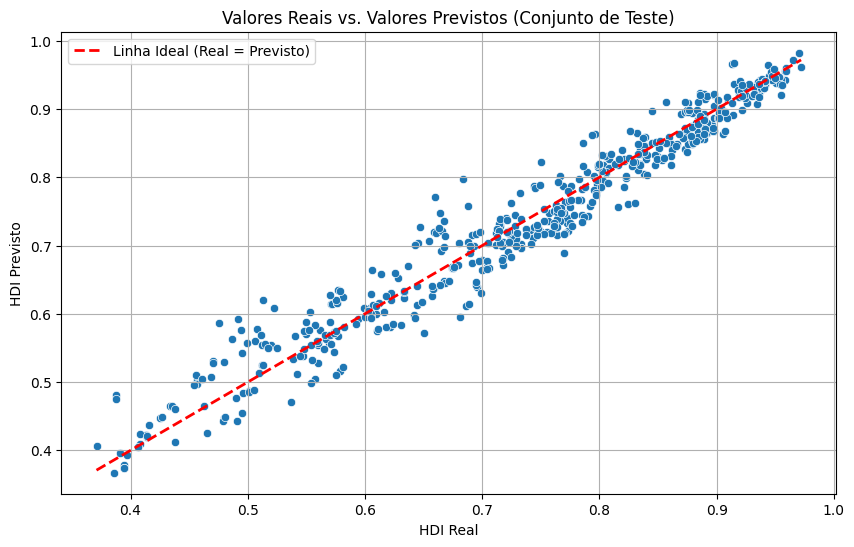

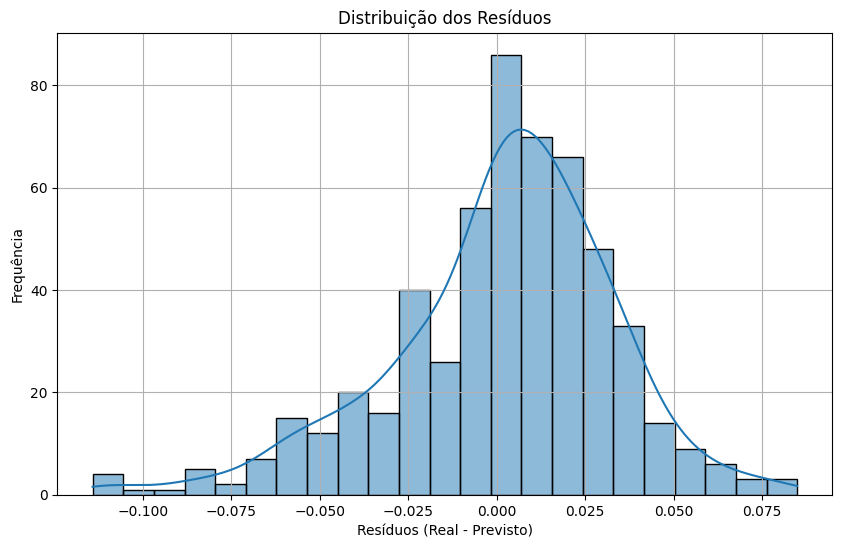

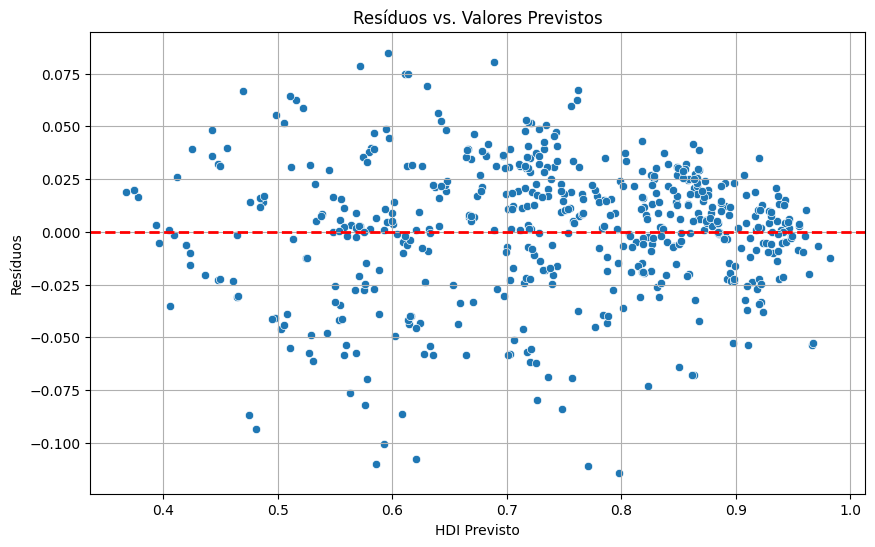

In [65]:
# Gráfico de dispersão da reta linear com as amostras (reais vs previstos) no teste:
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_pred)
plt.title('Valores Reais vs. Valores Previstos (Conjunto de Teste)')
plt.xlabel('HDI Real')
plt.ylabel('HDI Previsto')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--', lw=2, label='Linha Ideal (Real = Previsto)')
plt.legend()
plt.grid(True)
plt.show()

# Gráfico de barras dos resíduos
# Um bom modelo deve ter resíduos seguindo uma distribuição aproximadamente normal neste gráfico (parábola)
residuos = y_test - y_pred
plt.figure(figsize=(10, 6))
sns.histplot(residuos, kde=True)
plt.title('Distribuição dos Resíduos')
plt.xlabel('Resíduos (Real - Previsto)')
plt.ylabel('Frequência')
plt.grid(True)
plt.show()

# Gráfico da distribuição dos resíduos contra os valores previstos
# Se os resíduos estiverem bons, devem estar próximos da reta definida em 0, e não devem mostrar padrão ou tendência para qualquer um dos lados
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_pred, y=residuos)
plt.axhline(y=0, color='red', linestyle='--', lw=2)
plt.title('Resíduos vs. Valores Previstos')
plt.xlabel('HDI Previsto')
plt.ylabel('Resíduos')
plt.grid(True)
plt.show()